In [1]:
%load_ext autoreload
%autoreload 2


from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

import sys
sys.path.append('../src/')
sys.path.append('../tests/')
from tests import *
from time import time


from utils import *
from Instance import *
from Solution import *
from metaheuristic_approach import *


from copy import deepcopy
from time import time


##### MILP MODEL #####
import gurobipy as gp
from gurobipy import GRB

from first_model import *



# fonction de validation des chromosomes
from validator_metaheuristique import (
    validate_best_chromosomes,
    print_validation_summary,
)

#fonction de validation des solutions MILP
from validator_model import (
    solve_and_validate_model,
    validate_model_solutions,
    print_validation_summary,
    validate_model_solution,
)



# 1. Instances

In [2]:
TIME_DAY = 42 # 42 unités de temps = 1 journée de travail soit 7h
# 1unité de temps = 10 minutes

In [3]:
time_type_of_jobs = {
    "small": (3, 9),
    "medium": (9, 18),
    "long": (18, 42)
}

In [4]:
NB_INSTANCES = 10

In [5]:
instance_seed = []
for i in range(NB_INSTANCES):
    instance_seed.append(np.random.randint(1, 1000)) # pour générer un nombre aléatoire entre 1 et 1000 (inclus)
print(f"instance_seed: {instance_seed}")
# instance_seed[3] = 289
#[687, 638, 300, 289, 667]

instance_seed: [288, 533, 623, 658, 342, 426, 879, 342, 900, 802]


In [6]:
config_instances = []
for i in range(NB_INSTANCES):
    seed = instance_seed[i]
    config_instance = {
        "seed": seed,

        "nb_jobs": 10,
        "nb_workers": 4,
        "nb_professions": 4,
        "proportion_tasks_per_profession": [0.25, 0.25, 0.25, 0.25], # [profession 1, profession 2, profession 3, profession 4]
        "max_nb_operations": 6,
        "nb_tasks" : "lower", # "lower", "medium", "high"

        # "proportion_jobs": [0.3, 0.4, 0.3], # [small_jobs, medium_jobs, long_jobs]

        "proportion_tasks_without_collaborative_work": 0.2,
        "proportion_tasks_level_required": 0.1,

        "proportion_tasks_times" : [0.3, 0.4, 0.3], # [small_tasks (30 unités), medium_tasks (), long_tasks]
        "time_type_of_jobs" : time_type_of_jobs,
        "proportion_tasks_levels":[ 0.1, 0.1, 0.4, 0.4], # [level 1, level 2, level 3, level 4]

        "proportion_workers_levels":[ 0.3, 0.3, 0.1, 0.1], # [level 1, level 2, level 3, level 4]

        "at_least_a_worker_have_competence_for_each_profession": True
    }
    config_instances.append(config_instance)

In [7]:
instances = []
for i in range(NB_INSTANCES):
    instance = Instance()
    instance.from_config(config_instances[i])
    instances.append(instance)

set
[{64, 3, 36, 6, 9, 10, 11, 41, 13, 42, 18, 51, 63}, {0, 4, 5, 8, 14, 15, 16, 17, 20, 21, 22, 23, 25, 26, 30, 31, 33, 34, 38, 40, 44, 46, 47, 52, 53, 54, 56, 61, 62, 65}, {1, 2, 7, 12, 19, 24, 27, 28, 29, 32, 35, 37, 39, 43, 45, 48, 49, 50, 55, 57, 58, 59, 60}]
set
[{3, 4, 5, 7, 11, 15, 19, 23, 25, 27, 28, 30, 36, 49, 50, 55, 57, 60, 62}, {9, 12, 14, 16, 17, 18, 29, 31, 34, 37, 38, 39, 40, 41, 42, 43, 47, 48, 51, 54, 59, 61, 63, 65}, {0, 1, 2, 6, 8, 10, 13, 20, 21, 22, 24, 26, 32, 33, 35, 44, 45, 46, 52, 53, 56, 58, 64}]
set
[{33, 3, 4, 38, 43, 14, 15, 46, 22, 55, 25, 59, 28, 57}, {6, 7, 8, 9, 11, 13, 16, 17, 18, 20, 21, 26, 27, 29, 31, 32, 35, 36, 37, 39, 41, 44, 47, 48, 49, 51, 52, 53, 56, 60, 61, 65}, {0, 1, 2, 5, 10, 12, 19, 23, 24, 30, 34, 40, 42, 45, 50, 54, 58, 62, 63, 64}]
set
[{64, 2, 3, 5, 37, 40, 9, 44, 51, 20, 61, 55, 58, 59, 29}, {0, 1, 6, 8, 11, 14, 15, 16, 17, 18, 22, 23, 26, 27, 28, 31, 32, 33, 34, 36, 38, 39, 42, 46, 47, 50, 53, 54, 56, 57, 60}, {4, 7, 10, 12, 13, 1

In [8]:
# # conversion des temps en int pour faciliter calcules et comparaisons
# for instance in instances:
#     instance.tasks_times = np.array(instance.tasks_times, dtype=int)

In [9]:
# print(instance)

In [10]:
# instance.view_difficulty_and_metier_of_each_task(verbose=True)

ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


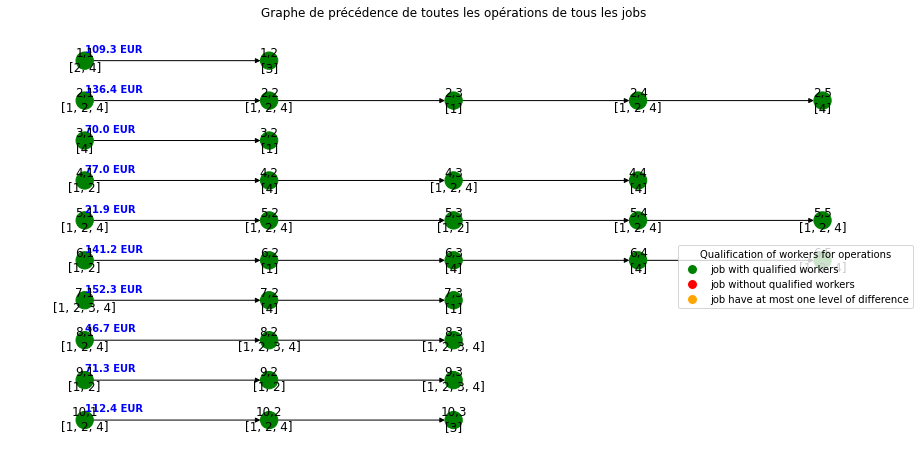

ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


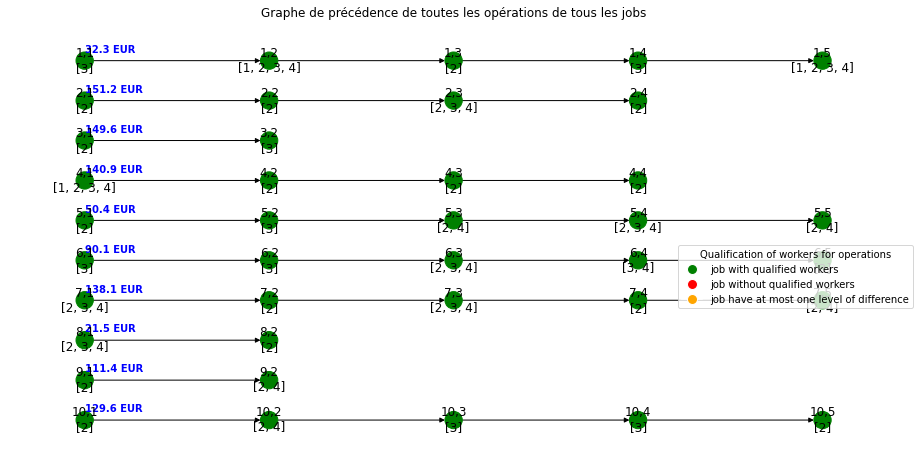

ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


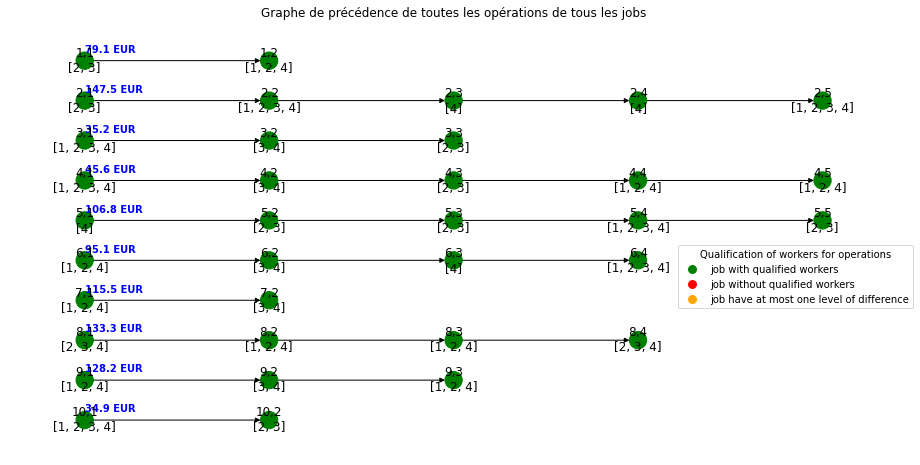

ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


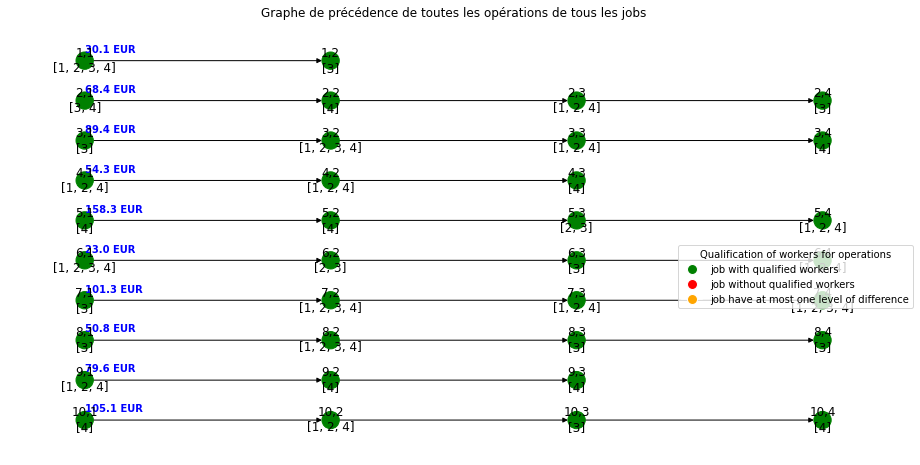

ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


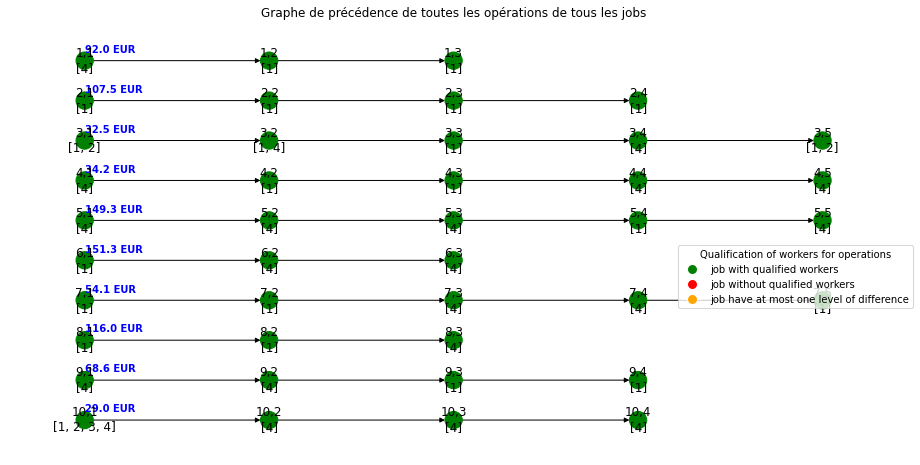

ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


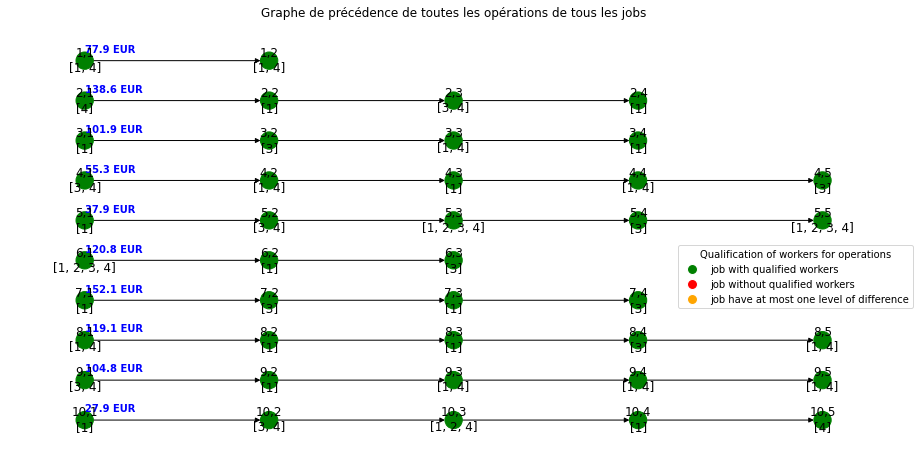

ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


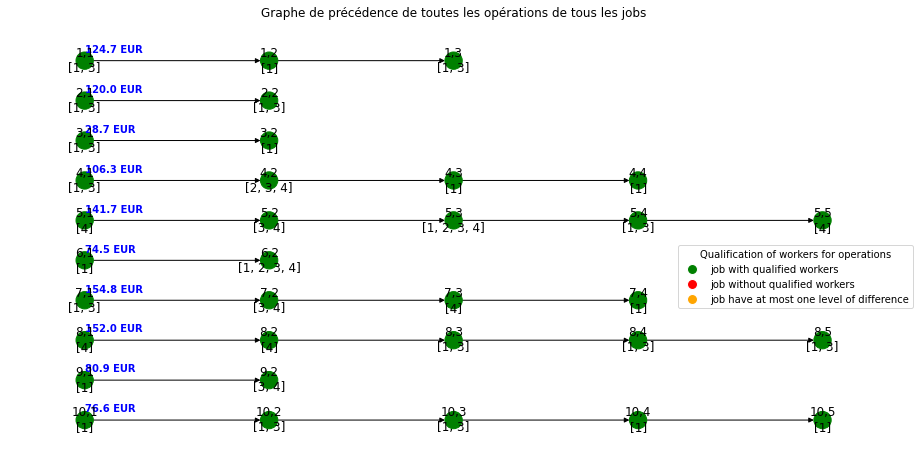

ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


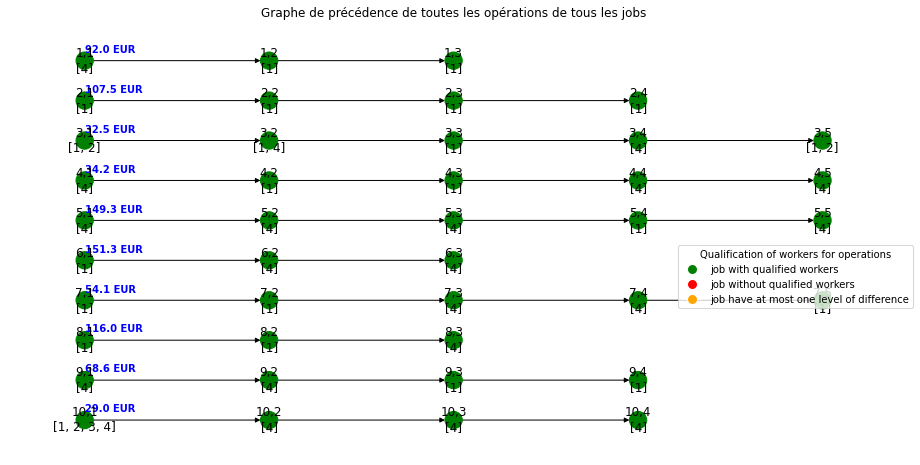

ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


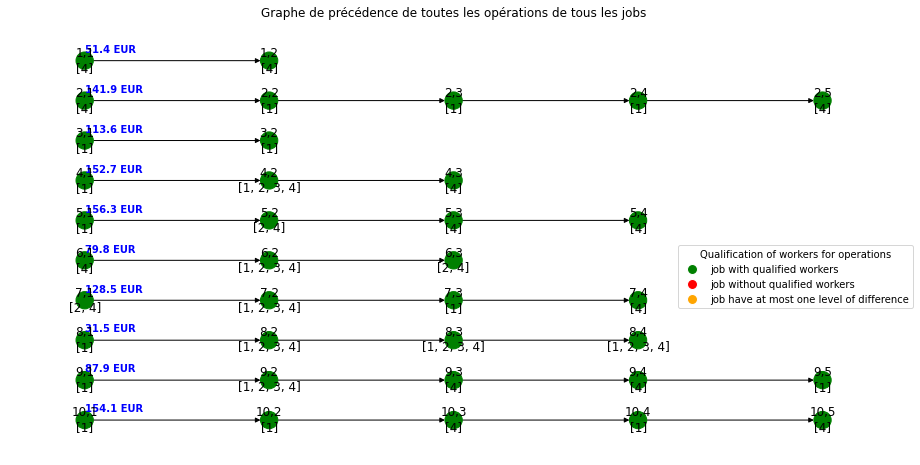

ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


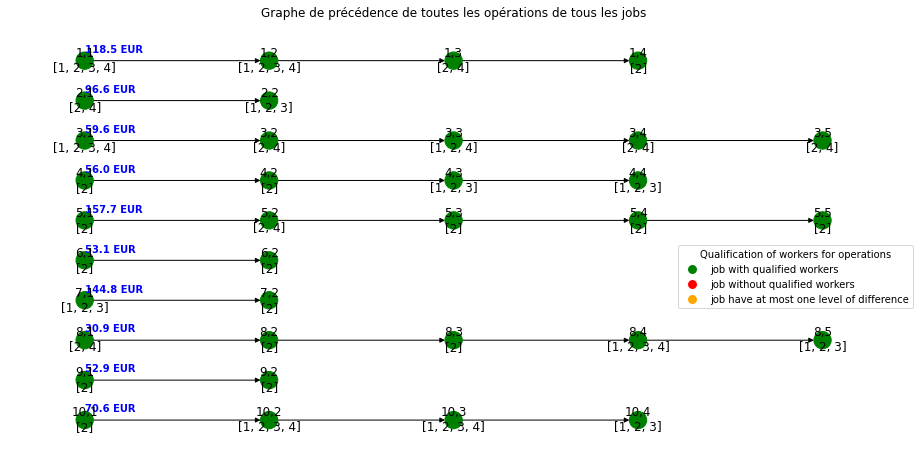

In [11]:
for instance in instances:
    visualization_before_scheduling(instance, not_qualified=True)

In [12]:
instance_seed

[288, 533, 623, 658, 342, 426, 879, 342, 900, 802]

---

In [13]:
# TIME_LIMIT_MAKESPAN = instance.sum_of_job_alone() /2
# print("temps total laissé pour le scheduling :", TIME_LIMIT_MAKESPAN)
# print("temps total nécessaire pour faire tous les jobs en travaillant seul :", instance.sum_of_job_alone())

In [14]:
constraints_config_baseline = {"job_with_no_skills": False,
                        "constrained_makespan": 20,
                        "no_base_worker" : False,
                        "no_solo_tasks": False,
                 }

constraints_config_solo_no_level = {"job_with_no_skills": 1,
                        "constrained_makespan": 20,
                        "no_base_worker" : False,
                        "no_solo_tasks": False,
                 }

constraints_config_no_base_worker = {"job_with_no_skills": False,
                        "constrained_makespan": 20,
                        "no_base_worker" : True,
                        "no_solo_tasks": False,
                 }

constraints_config_no_teaching = {"job_with_no_skills": False,
                        "constrained_makespan": 20,
                        "no_base_worker" : False,
                        "no_solo_tasks": False,
                        "no_teaching_tasks": True,
                 }

constraints_config_no_duo = {"job_with_no_skills": False,
                        "constrained_makespan": 20,
                        "no_base_worker" : False,
                        "no_solo_tasks": False,
                        "no_teaching_tasks": False,
                        "all_solo_tasks" : True,
                 }
              

weights = {
    "profit" : 1,
    "skills" : 1,
    "cognitive_load" : 1
    }

In [15]:
list_constraints_config = [
    constraints_config_baseline,
    constraints_config_solo_no_level,
    constraints_config_no_base_worker,
    constraints_config_no_teaching,
    constraints_config_no_duo
]

---

In [16]:
solutions = [ [] for i in range(len(instances)) ] #(nb_instances, nb_constraints_config)
temps = np.zeros((len(instances), len(list_constraints_config))) #(nb_instances, nb_constraints_config)

# 2.1 MILP

In [63]:
solutions[0][0]._resale_price_job_done_plus_task_done()

190.67631951670256

In [17]:
s = []
s_prime = []
df = []
df_prime = []

weights = {
    "profit" : 1,
    "skills" : 0,
    "cognitive_load" : 0
    }

for i in range(NB_INSTANCES):
    print("---------- instance:", i, " -----------")
    instance = instances[i]
    for j in range(len(list_constraints_config)):
        constraints_config = list_constraints_config[j]
        print("---------- constraint config:", j, " -----------")

        model = Model(instance)
        time_start = time.time()
        s = model.solve(objective="lexicographic", weight=weights, priority=[2, 1, 0], constraints_config=constraints_config, verbose=False)
        solutions[i].append(s)
        print("Nombre de jobs terminés:", s.get_nb_jobs_done())
        print("Nombre de jobs commencés mais pas terminés:", s.get_nb_jobs_beginned_but_not_done())
        print("Prix de revente des jobs terminés:", s.get_resale_price_job_done())
        print("Nombre de tâches terminées:", s.get_nb_tasks_done())
        temps[i][j] = time.time() - time_start
        print("temps de résolution:", temps[i][j], "s")


---------- instance: 0  -----------
---------- constraint config: 0  -----------

 ========== SOLVING MODEL ========== 
Set parameter Username
Academic license - for non-commercial use only - expires 2027-01-05
EPS= 0.0001
job with no skills desactived
nb_job_with_no_skills =  0
limite MAKESPAN =  20
constrained makespan activated with limit = 20
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 20
init affectation variables desactivated
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 190.67631951670256
nObjectives 3
nSolutions 10
et la -> 20
Borne sup makespan: 20
Nombre de jobs terminés: 2
Nombre de jobs commencés mais pas terminés: 5
Prix de revente des jobs terminés: 180.67631951670256
Nombre de tâches terminées: 10.0
temps de résolution: 58.43554902076721 s
---------- constraint config: 1  -----------

 ========== SOLVING MODEL ========== 
EPS= 0.0001
job with no skills activated
nb_job_with_no_skills

In [18]:
inst = 0
scen = 0

for i in range(len(solutions)):
    row, ok = validate_model_solution(
        instance=instances[0],
        solution=solutions[inst][scen],
        constraints_config=list_constraints_config[scen],
    )
    display(pd.DataFrame([row]))

for i in range(len(solutions)):
    df, summary = validate_model_solutions(instance=instances[i], solutions=solutions[i], constraint_configs=list_constraints_config)
    print("\n\ninstance", i, ":", summary)

Exécution du test solution_valide...
nb_job_no_skills=0
Exécution du test base_worker...
Exécution du test need_level_if_solo...


,Nom,C_max,Profit,Profit_job_done,Skill_gain,Cognitive_load,solution_valide,base_worker,need_level_if_solo,OK
0,solution,20.0,190.67632,180.67632,0.5,17.352086,PASS,PASS,PASS,TRUE


Exécution du test solution_valide...
nb_job_no_skills=0
Exécution du test base_worker...
Exécution du test need_level_if_solo...


,Nom,C_max,Profit,Profit_job_done,Skill_gain,Cognitive_load,solution_valide,base_worker,need_level_if_solo,OK
0,solution,20.0,190.67632,180.67632,0.5,17.352086,PASS,PASS,PASS,TRUE


Exécution du test solution_valide...
nb_job_no_skills=0
Exécution du test base_worker...
Exécution du test need_level_if_solo...


...

Exécution du test solution_valide...
nb_job_no_skills=0
Exécution du test base_worker...
Exécution du test need_level_if_solo...


,Nom,C_max,Profit,Profit_job_done,Skill_gain,Cognitive_load,solution_valide,base_worker,need_level_if_solo,OK
0,solution,20.0,190.67632,180.67632,0.5,17.352086,PASS,PASS,PASS,TRUE


Exécution du test solution_valide...
nb_job_no_skills=0
Exécution du test base_worker...
Exécution du test need_level_if_solo...


,Nom,C_max,Profit,Profit_job_done,Skill_gain,Cognitive_load,solution_valide,base_worker,need_level_if_solo,OK
0,solution,20.0,190.67632,180.67632,0.5,17.352086,PASS,PASS,PASS,TRUE


Exécution du test solution_valide...
nb_job_no_skills=0
Exécution du test base_worker...
Exécution du test need_level_if_solo...
Exécution du test solution_valide...
nb_job_no_skills=1
Exécution du test base_worker...
Exécution du test solo_no_level_difference...
Exécution du test solution_valide...
nb_job_no_skills=0
Exécution du test need_level_if_solo...
Exécution du test solution_valide...
nb_job_no_skills=0
Exécution du test base_worker...
Exécution du test no_teaching_tasks...
Exécution du test need_level_if_solo...
Exécution du test solution_valide...
nb_job_no_skills=0
Exécution du test base_worker...
Exécution du test need_level_if_solo...


instance 0 : {'total': 5, 'passed': 5, 'failed': 0, 'all_passed': True}
Exécution du test solution_valide...
nb_job_no_skills=0
Exécution du test base_worker...
Exécution du test need_level_if_solo...
Exécution du test solution_valide...
nb_job_no_skills=1
Exécution du test base_worker...
Exécution du test solo_no_level_difference...
Exécu

In [19]:
labels = ["baseline",
    "solo_no_level",
    "no_base_worker",
    "no_teaching",
    "no_duo"
]
dfs = []
for i in range(len(solutions)):
    dfs.append(Solution.solutions_to_df(solutions[i], labels))


In [20]:
temps

array([[ 58.43554902,  64.68621588,  85.0565002 ,  17.70255804,
          5.12627101],
       [ 11.57389379,   8.78055191,  64.14867401,   6.66100097,
          5.79976225],
       [ 79.106251  ,  64.04108214, 191.96774006,  20.35699296,
          4.54173064],
       [  6.4504869 ,  10.63071895, 156.65579224,   5.60158086,
          4.33214378],
       [ 10.83147383,  11.54482698,  59.81856203,   6.68912315,
          5.2838769 ],
       [ 13.73271585,  13.58810091, 126.93589997,   7.23767328,
          5.82144308],
       [  7.24315691,   7.23339081,  67.12504911,   5.22711086,
          3.74183106],
       [ 11.07948303,  12.16262507,  56.52516508,   6.42431903,
          4.97860909],
       [  5.44667077,   8.21322012,  28.33807898,   4.6363709 ,
          4.10875225],
       [ 23.60487509,  24.90242004,  66.63177896,  16.90711379,
          5.13409901]])

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math


def plot_scenario_metrics(
    dfs,
    metrics=None,
    error="std",
    ncols=3,
    figsize_per_subplot=(5, 4),
    rotate_labels=30
):
    """
    Compare les différents scénarios MILP sur plusieurs instances/seeds.

    Paramètres
    ----------
    dfs : list
        Soit :
            dfs[seed] = DataFrame
        soit :
            dfs[instance][seed] = DataFrame

        Chaque DataFrame doit avoir les scénarios dans l'index :
            baseline
            solo_no_level
            no_base_worker
            ...

        et les métriques dans les colonnes.

    metrics : list[str] ou None
        Métriques à afficher.
        Si None, toutes les colonnes numériques sont utilisées.

    error : {"std", "sem", "ci95", None}
        Barre d'erreur affichée :
            std  : écart-type
            sem  : erreur standard
            ci95 : intervalle de confiance approximatif à 95 %
            None : aucune barre d'erreur

    ncols : int
        Nombre de colonnes de subplots.

    figsize_per_subplot : tuple
        Taille approximative de chaque subplot.

    rotate_labels : float
        Rotation des noms de scénarios.

    Retourne
    --------
    all_results : DataFrame
        Toutes les données regroupées.

    stats : DataFrame
        Statistiques par scénario.
    """

    # ---------------------------------------------------------
    # 1. Transformer dfs en une liste de DataFrames
    # ---------------------------------------------------------

    records = []

    # Cas dfs = [DataFrame, DataFrame, ...]
    if len(dfs) > 0 and isinstance(dfs[0], pd.DataFrame):

        for run_id, df in enumerate(dfs):
            tmp = df.copy()

            tmp["scenario"] = tmp.index
            tmp["instance"] = 0
            tmp["seed"] = run_id

            records.append(tmp.reset_index(drop=True))

    # Cas dfs = [[df_seed1, df_seed2, ...], ...]
    else:

        for instance_id, instance_dfs in enumerate(dfs):

            for seed_id, df in enumerate(instance_dfs):

                tmp = df.copy()

                tmp["scenario"] = tmp.index
                tmp["instance"] = instance_id
                tmp["seed"] = seed_id

                records.append(tmp.reset_index(drop=True))

    # ---------------------------------------------------------
    # 2. Regrouper toutes les expériences
    # ---------------------------------------------------------

    all_results = pd.concat(records, ignore_index=True)

    # Colonnes à ignorer
    metadata_cols = ["scenario", "instance", "seed"]

    if metrics is None:
        metrics = [
            col
            for col in all_results.columns
            if col not in metadata_cols
            and pd.api.types.is_numeric_dtype(all_results[col])
        ]

    # ---------------------------------------------------------
    # 3. Statistiques par scénario
    # ---------------------------------------------------------

    grouped = all_results.groupby("scenario")[metrics]

    mean = grouped.mean()
    std = grouped.std()
    count = grouped.count()

    if error == "std":
        err = std

    elif error == "sem":
        err = std / np.sqrt(count)

    elif error == "ci95":
        err = 1.96 * std / np.sqrt(count)

    elif error is None:
        err = None

    else:
        raise ValueError(
            "error doit être 'std', 'sem', 'ci95' ou None"
        )

    # Garder l'ordre des scénarios du premier DataFrame
    first_df = dfs[0] if isinstance(dfs[0], pd.DataFrame) else dfs[0][0]

    scenario_order = [
        scenario
        for scenario in first_df.index
        if scenario in mean.index
    ]

    mean = mean.loc[scenario_order]

    if err is not None:
        err = err.loc[scenario_order]

    # ---------------------------------------------------------
    # 4. Création des graphiques
    # ---------------------------------------------------------

    n_metrics = len(metrics)
    nrows = math.ceil(n_metrics / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(
            figsize_per_subplot[0] * ncols,
            figsize_per_subplot[1] * nrows
        ),
        squeeze=False
    )

    axes = axes.flatten()

    x = np.arange(len(scenario_order))

    for i, metric in enumerate(metrics):

        ax = axes[i]

        y = mean[metric].values

        if err is not None:
            yerr = err[metric].values
        else:
            yerr = None

        ax.bar(
            x,
            y,
            yerr=yerr,
            capsize=4
        )

        ax.set_title(metric)
        ax.set_xticks(x)
        ax.set_xticklabels(
            scenario_order,
            rotation=rotate_labels,
            ha="right"
        )

        ax.grid(
            axis="y",
            alpha=0.25
        )

    # Supprimer les axes inutilisés
    for i in range(n_metrics, len(axes)):
        fig.delaxes(axes[i])

    fig.suptitle(
        "Comparaison des scénarios MILP",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # Tableau statistique pratique
    # ---------------------------------------------------------

    stats = mean.copy()

    return all_results, stats

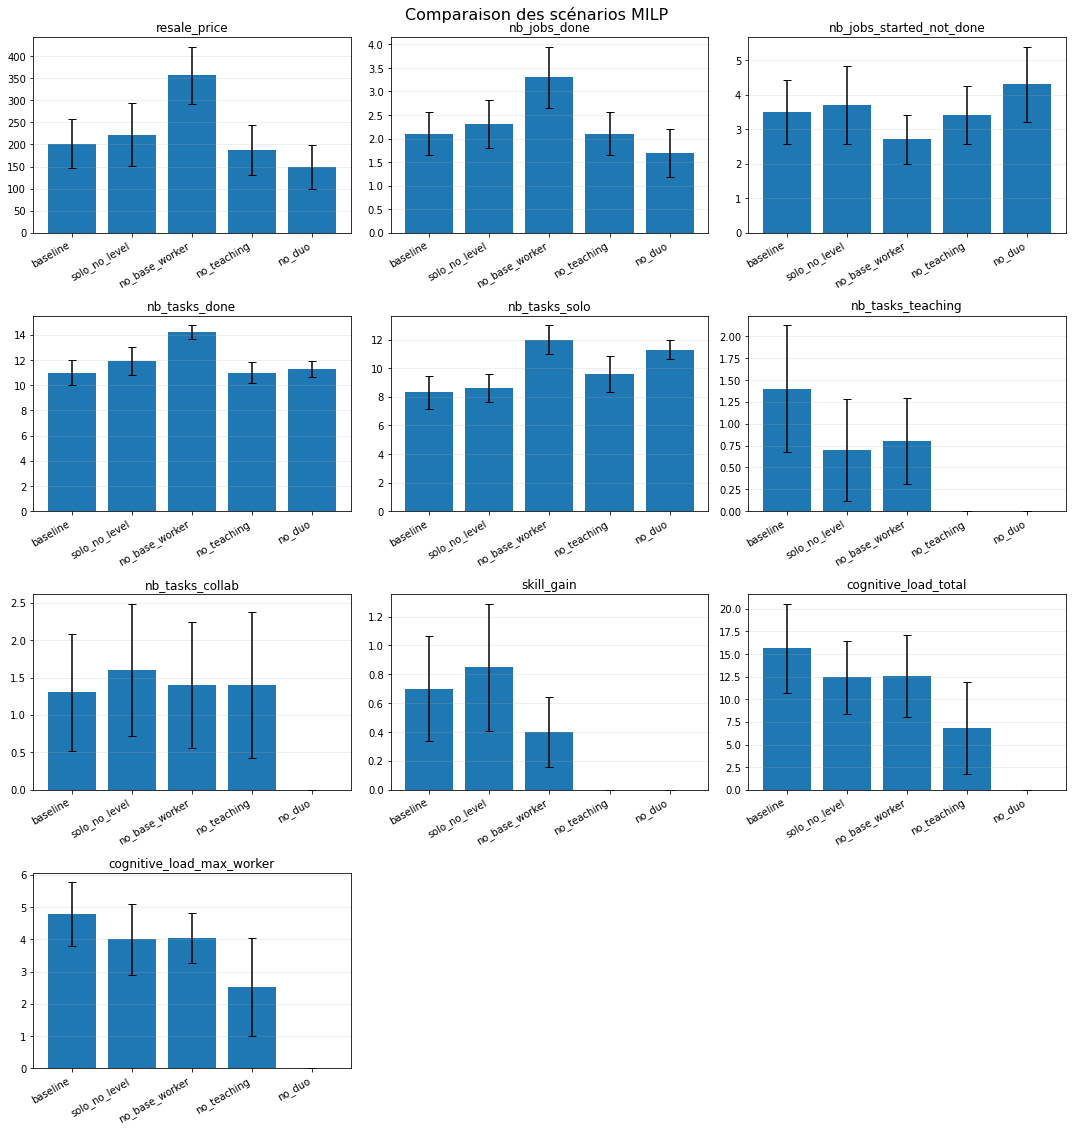

In [26]:
metrics = [
    "resale_price",
    "nb_jobs_done",
    "nb_jobs_started_not_done",
    "nb_tasks_done",
    "nb_tasks_solo",
    "nb_tasks_teaching",
    "nb_tasks_collab",
    "skill_gain",
    "cognitive_load_total",
    "cognitive_load_max_worker"
]

all_results, stats = plot_scenario_metrics(
    dfs,
    metrics=metrics,
    error="ci95",
    ncols=3
)

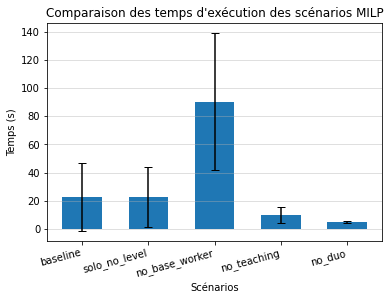

In [27]:
# comparaison de temps des differents scénarios
mean_time = np.mean(temps, axis=0)
x = np.arange(len(labels))
plt.bar(
    x,
    mean_time,
    width=0.6,
    yerr=np.std(temps, axis=0),
    capsize=4
)
plt.xticks(x, labels, rotation=15, ha="right")
plt.grid(axis="y", alpha=0.5)
plt.title("Comparaison des temps d'exécution des scénarios MILP")
plt.xlabel("Scénarios")
plt.ylabel("Temps (s)")
plt.show()

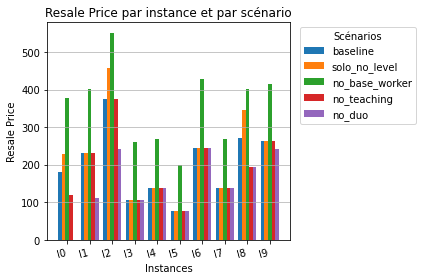

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Nombre d'instances et de scénarios
n_instances = len(solutions)
n_scenarios = len(solutions[0])

# Positions des instances sur l'axe X
x = np.arange(n_instances)

# Largeur des barres
width = 0.8 / n_scenarios

for j in range(n_scenarios):

    # Resale price du scénario j pour toutes les instances
    resale_prices = [
        solutions[i][j].get_resale_price_job_done()
        for i in range(n_instances)
    ]

    # Décalage pour centrer les barres autour de chaque instance
    offset = (j - (n_scenarios - 1) / 2) * width

    plt.bar(
        x + offset,
        resale_prices,
        width=width,
        label=labels[j]
    )

# Noms des instances sur l'axe X
plt.xticks(
    x,
    [f"I{i}" for i in range(n_instances)],
    rotation=15,
    ha="right"
)

plt.title("Resale Price par instance et par scénario")
plt.xlabel("Instances")
plt.ylabel("Resale Price")

# La légende correspond maintenant aux scénarios
plt.legend(
    title="Scénarios",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(axis="y", alpha=0.9)
plt.tight_layout()
plt.show()




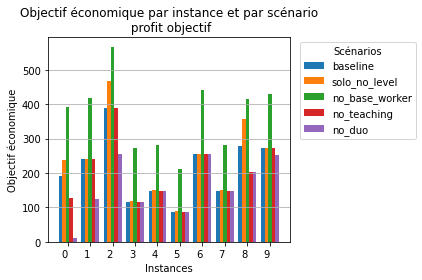

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# Nombre d'instances et de scénarios
n_instances = len(solutions)
n_scenarios = len(solutions[0])

# Positions des instances sur l'axe X
x = np.arange(n_instances)

# Largeur des barres
width = 0.8 / n_scenarios

for j in range(n_scenarios):

    # Resale price du scénario j pour toutes les instances
    resale_prices = [
        solutions[i][j]._resale_price_job_done_plus_task_done()
        for i in range(n_instances)
    ]

    # Décalage pour centrer les barres autour de chaque instance
    offset = (j - (n_scenarios - 1) / 2) * width

    plt.bar(
        x + offset,
        resale_prices,
        width=width,
        label=labels[j]
    )

# Noms des instances sur l'axe X
plt.xticks(
    x,
    [f"{i}" for i in range(n_instances)],
    rotation=0,
    ha="right"
)

plt.title("Objectif économique par instance et par scénario\n profit objectif")
plt.xlabel("Instances")
plt.ylabel("Objectif économique")

# La légende correspond maintenant aux scénarios
plt.legend(
    title="Scénarios",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(axis="y")
plt.tight_layout()
plt.show()




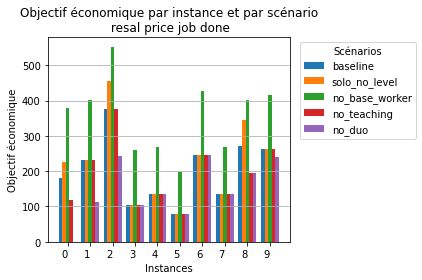

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# Nombre d'instances et de scénarios
n_instances = len(solutions)
n_scenarios = len(solutions[0])

# Positions des instances sur l'axe X
x = np.arange(n_instances)

# Largeur des barres
width = 0.8 / n_scenarios

for j in range(n_scenarios):

    # Resale price du scénario j pour toutes les instances
    resale_prices = [
        solutions[i][j].get_resale_price_job_done()
        for i in range(n_instances)
    ]

    # Décalage pour centrer les barres autour de chaque instance
    offset = (j - (n_scenarios - 1) / 2) * width

    plt.bar(
        x + offset,
        resale_prices,
        width=width,
        label=labels[j]
    )

# Noms des instances sur l'axe X
plt.xticks(
    x,
    [f"{i}" for i in range(n_instances)],
    rotation=0,
    ha="right"
)

plt.title("Objectif économique par instance et par scénario\n resal price job done")
plt.xlabel("Instances")
plt.ylabel("Objectif économique")

# La légende correspond maintenant aux scénarios
plt.legend(
    title="Scénarios",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(axis="y")
plt.tight_layout()
plt.show()




---

---

In [52]:
weights = {
    "profit" : 100,
    "skills" : 10,
    "cognitive_load" : 1
    }

In [77]:
ONE_NB_SEED = 5
MAX_EVAL = 5000

encs = [Encoding_Dicos(instances[i]) for i in range(len(instances))]
gens = [ChromosomeGenerator(instances[i], encs[i], constraints_config=constraints_config_baseline) for i in range(len(instances))]
decs = [Decoder(instances[i], encs[i], constraints_config=constraints_config_baseline) for i in range(len(instances))]
evals = [Evaluator(decs[i], weights) for i in range(len(instances))]
sel = BestSelector()

# enc   = Encoding_Dicos(instances[indx_inst])
# gen   = ChromosomeGenerator(instances[indx_inst], enc, constraints_config=constraints_config_baseline)
# dec   = Decoder(instances[indx_inst], enc, constraints_config=constraints_config_baseline)
# eval  = Evaluator(dec, weights)
# sel   = BestSelector()


## Random Search

In [78]:
rs_times = np.zeros((len(instances), ONE_NB_SEED))
rs_all_viewed = [ [] for _ in range(len(instances)) ]
rs_best_list = [ [] for _ in range(len(instances)) ]
rs_index_best_list = [ [] for _ in range(len(instances)) ]

In [83]:
for i in range(len(instances)):
    for nb_seed in range(ONE_NB_SEED):

        rs = RandomSearch(gens[i], evals[i])
        t = time.time()

        av, bl, indx_bests, best_c = rs.run(MAX_EVAL, verbose=False)
        
        rs_times[i, nb_seed] = time.time() - t

        rs_all_viewed[i].append(av)
        rs_best_list[i].append(bl)
        rs_index_best_list[i].append(indx_bests)
        print(f"RS I{i+1} terminé  (moy {rs_times[i].mean():.1f}s/seed)")
        print(f"Best fitness: {best_c.fitness}, Best objectives: {best_c.objectives}")
        print(f"Best index: {rs_index_best_list[i][nb_seed]}")
        print("-----")


Random Search Iterations:   1%|▏         | 70/5000 [00:00<00:14, 343.71it/s]

RS I1 terminé  (moy 18.2s/seed)
Best fitness: 18701.54159083786, Best objectives: (187.32636412588232, 1.3412230546351083, -44.507052296721085)
Best index: [0, 2, 4, 36, 44, 104, 206, 498, 665, 1865, 3218, 4850]
-----


Random Search Iterations:   1%|          | 37/5000 [00:00<00:13, 368.21it/s]

RS I1 terminé  (moy 16.1s/seed)
Best fitness: 18789.58308280782, Best objectives: (188.32636412588232, 1.3412230546351083, -56.46556032676018)
Best index: [0, 1, 24, 1715, 2643]
-----


Random Search Iterations:   0%|          | 19/5000 [00:00<00:27, 184.26it/s]

...

RS I10 terminé  (moy 14.0s/seed)
Best fitness: 27080.108298029918, Best objectives: (271.2541049255985, 0.0, -45.30219452992951)
Best index: [0, 4, 13, 22, 29, 31, 35, 276, 465, 1583, 1588, 1652, 3581]
-----


Random Search Iterations:   0%|          | 8/5000 [00:00<01:02, 79.47it/s]

RS I10 terminé  (moy 20.9s/seed)
Best fitness: 27079.877096474156, Best objectives: (271.2541049255985, 0.0, -45.53339608569001)
Best index: [0, 4, 9, 18, 110, 162, 182, 1225, 1512, 1945]
-----


Random Search Iterations: 100%|██████████| 5000/5000 [00:22<00:00, 221.37it/s]


RS I10 terminé  (moy 25.4s/seed)
Best fitness: 27078.577096474157, Best objectives: (271.2541049255985, 0.0, -46.83339608569001)
Best index: [0, 4, 7, 14, 142, 381, 1493, 1585, 2726, 3596]
-----


In [87]:
# for i in range(len(instances)):
#     for j in range(ONE_NB_SEED):
#         row, ok = validate_model_solution(
#             instance=instances[i],
#             solution=decs[i].decode_solution(rs_best_list[i][j][-1]),
#             constraints_config=list_constraints_config[scen],
#         )
#         display(pd.DataFrame([row]))

In [91]:
# for i in range(len(instances)):
#     for j in range(ONE_NB_SEED):
#         print(rs_best_list[i][j][-1].fitness)
#         print(rs_best_list[i][j][-1].objectives)
#         print("--")

In [92]:
# for i in range(len(instances)):
#     for j in range(ONE_NB_SEED):
#         print(rs_index_best_list[i][j])

In [93]:
# for i in range(len(instances)):
#     print(f"Instance {i+1}:")
#     for j in range(ONE_NB_SEED):
#         print(f"  Seed {j+1}:")
#         print(f"    Fitness: {rs_best_list[i][j].fitness}")
#         print(f"    Objectives: {rs_best_list[i][j].objectives}")
#         print(f"    Index Best: {rs_index_best_list[i][j]}")
#     print("-----")

In [125]:
rs_best_list_fitness = [ [] for _ in range(len(instances)) ]
for i in range (len(instances)):
    for j in range(ONE_NB_SEED):
        rs_best_list_fitness[i].append([c.fitness for c in rs_best_list[i][j]])
    

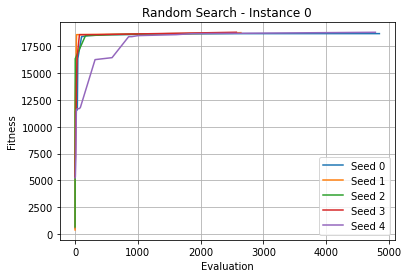

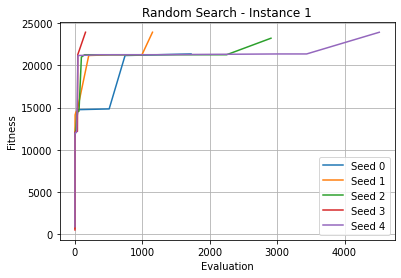

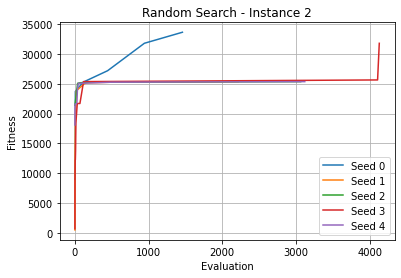

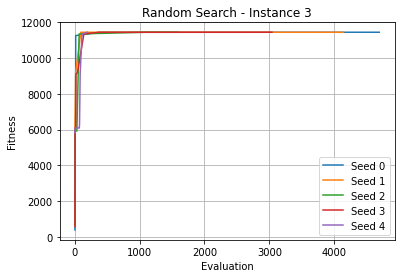

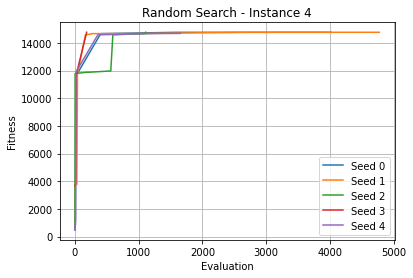

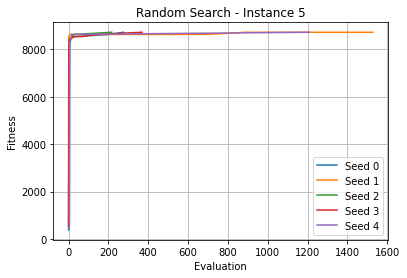

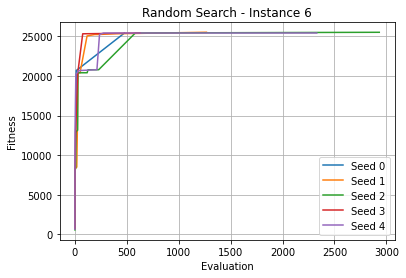

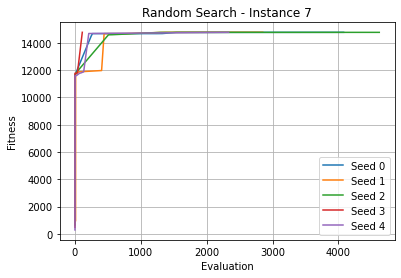

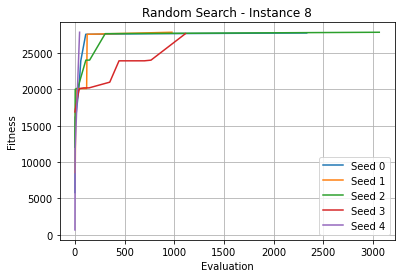

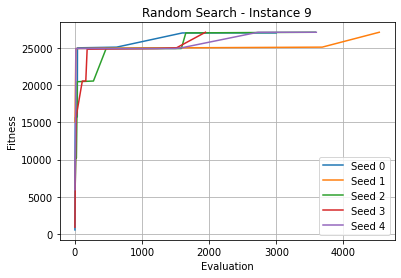

In [130]:
for i in range(len(instances)):
    for j in range(ONE_NB_SEED):
        plt.plot(rs_index_best_list[i][j], rs_best_list_fitness[i][j], label=f"Seed {j}")
        plt.grid()
        plt.xlabel("Evaluation")
        plt.ylabel("Fitness")
        plt.title(f"Random Search - Instance {i}")
        plt.legend()
    plt.show()

In [131]:
rs_best_list_objectif_economic = [ [] for _ in range(len(instances)) ]
for i in range (len(instances)):
    for j in range(ONE_NB_SEED):
        rs_best_list_objectif_economic[i].append([c.objectives[0] for c in rs_best_list[i][j]])
    

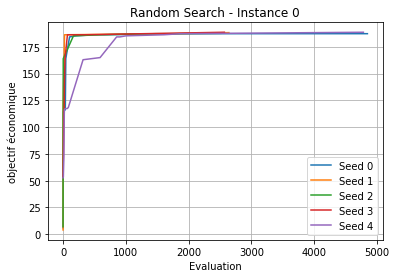

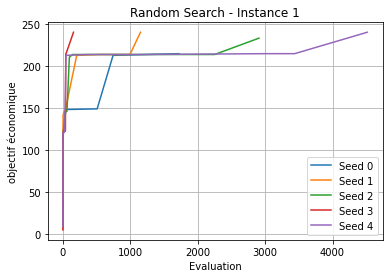

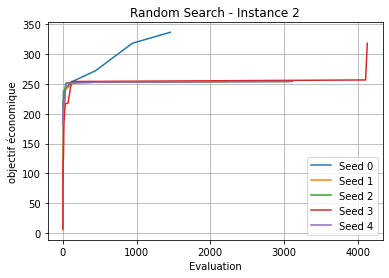

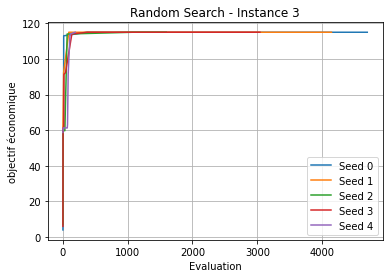

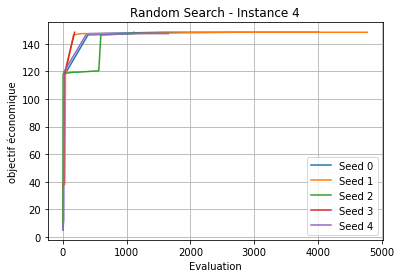

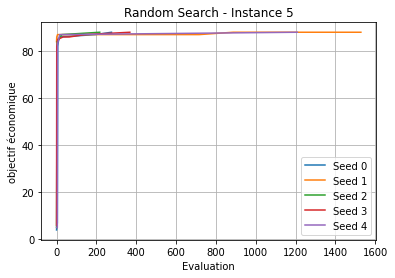

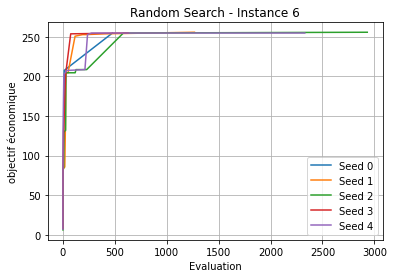

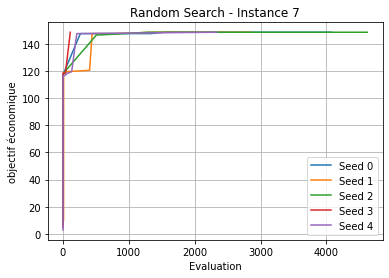

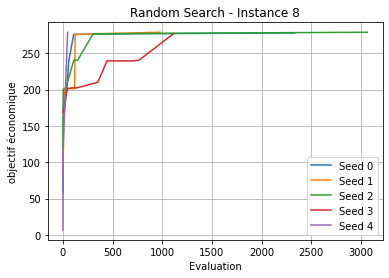

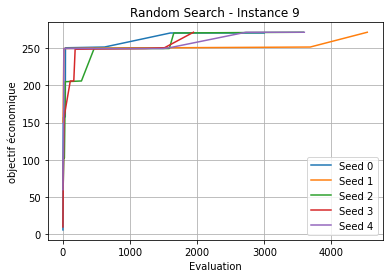

In [133]:
for i in range (len(instances)):
    for j in range(ONE_NB_SEED):
        plt.plot(rs_index_best_list[i][j], rs_best_list_objectif_economic[i][j], label=f"Seed {j}")
        plt.grid()
        plt.xlabel("Evaluation")
        plt.ylabel("objectif économique")
        plt.title(f"Random Search - Instance {i}")
    plt.legend()
    plt.show()

all_runs:
[[  5.         153.87912451 153.87912451 ... 382.4245086  382.4245086
  382.4245086 ]
 [  6.         151.87912451 151.87912451 ... 382.4245086  382.4245086
  382.4245086 ]
 [382.4245086  382.4245086  382.4245086  ... 382.4245086  382.4245086
  382.4245086 ]
 [152.87912451 248.06181196 248.06181196 ... 382.4245086  382.4245086
  382.4245086 ]
 [ 98.18268745  98.18268745 247.06181196 ... 290.24182115 290.24182115
  290.24182115]]


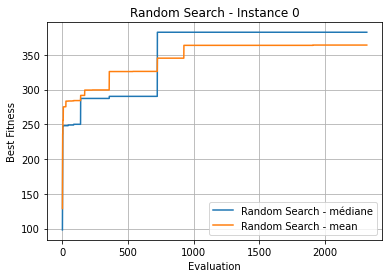

In [282]:
# Budget commun aux seeds
max_eval = min(rs_index_best_list[i][-1] for i in range(ONE_NB_SEED))

evaluations = np.arange(max_eval + 1)

all_runs = []

for i in range(ONE_NB_SEED):

    indices = np.array(rs_index_best_list[i])
    best_values = np.array(rs_best_list_objectif_economic[i])

    # Pour chaque évaluation, on cherche le dernier best-so-far connu
    pos = np.searchsorted(indices, evaluations, side="right") - 1
    # Valeurs du best-so-far à chaque évaluation
    run = np.full(len(evaluations), np.nan)

    valid = pos >= 0
    run[valid] = best_values[pos[valid]]

    all_runs.append(run)

all_runs = np.array(all_runs)
print("all_runs:")
print(all_runs)


# Médiane entre les seeds
median_rs = np.nanmedian(all_runs, axis=0)
mean_rs = np.mean(all_runs, axis = 0)

# Affichage
plt.plot(
    evaluations,
    median_rs,
    label="Random Search - médiane"
)

plt.plot(
    evaluations,
    mean_rs,
    label="Random Search - mean"
)

plt.grid()
plt.xlabel("Evaluation")
plt.ylabel("Best Fitness")
plt.title(f"Random Search - Instance {indx_inst}")
plt.legend()

plt.show()

In [159]:
def build_neighborhoods(gen, nb_job_no_skills=0):
    """Retourne la liste des voisinages à tester — modifier ici pour ajouter/retirer un voisinage."""
    return [
        (SwapOperationNeighborhood(n=10, nb_job_no_skills=nb_job_no_skills), "Swap OSC"),
        (MoveOneOperationNeighborhood(),                                      "Move OSC"),
        (MoveSecondWorkerNeighborhood(gen),                                   "Move SWAC"),
        (ChangebaseWorkerNeighborhood(nb_job_no_skills=nb_job_no_skills, generator=gen), "Change Base Worker"),
        (MoveJobNeighborhood(n=5), "Move Job"),  # k=1 perturbation moyenne
        (multipleNeighborhood_alternating(
            SwapOperationNeighborhood(n=5, nb_job_no_skills=nb_job_no_skills),
            MoveSecondWorkerNeighborhood(gen),
            nb_job_no_skills=nb_job_no_skills,
        ), "Alternating"),
        (RandomRestartNeighborhood(gen,1), "Random Restart"),
    ]

In [284]:
shaking = [
    ShuffleOperationsNeighborhood(n=3, nb_job_no_skills=0),
    ChangebaseWorkerNeighborhood(nb_job_no_skills=0, generator=gen),
]
neighborhoods = build_neighborhoods(gen, nb_job_no_skills=0)

In [163]:
ONE_NB_SEED = 10

In [168]:
vns_times = np.zeros((len(instances), ONE_NB_SEED))
vns_all_viewed = [ [] for _ in range(len(instances)) ]
vns_best_list = [ [] for _ in range(len(instances)) ]
vns_index_best_list = [ [] for _ in range(len(instances)) ]
vns_best_c = [ [] for _ in range(len(instances)) ]

for i in range(len(instances)):
# for i in range(1):
    print(f"VNS - Instance {i+1}/{len(instances)}")
    for nb_seed in range(ONE_NB_SEED):
        print(f"VNS - Seed {nb_seed+1}/{ONE_NB_SEED}")

        neighborhoods = build_neighborhoods(gens[i], nb_job_no_skills=0)

        vns = VNS(gens[i], evals[i], neighborhoods, sel, ls_patience=100)
        t = time.time()

        av, bl, indx_bests, best_c = vns.run(MAX_EVAL, verbose=False)
        
        vns_times[i][nb_seed] = time.time() - t
        vns_all_viewed[i].append(av)
        vns_best_list[i].append(bl)
        vns_index_best_list[i].append(indx_bests)
        vns_best_c[i].append(best_c)
        print(f"best fitness: {best_c.fitness}, best objectives: {best_c.objectives}")


VNS - Instance 1/10
VNS - Seed 1/10
Swap OSC - Move OSC - Move SWAC - Change Base Worker - Move Job - Alternating - Random Restart - 
Neighborhood current =  Swap OSC
Amélioration | fitness=16549.1963 | evals=182/5000 k= 0
Amélioration | fitness=16643.3954 | evals=785/5000 k= 0
Re - Run avec candidat moins performant
Amélioration | fitness=16644.0727 | evals=2590/5000 k= 0
Re - Run avec candidat moins performant
Amélioration | fitness=16457.1917 | evals=4086/5000 k= 0
Amélioration | fitness=16643.7819 | evals=4649/5000 k= 0
best fitness: 16644.072651682967, best objectives: (166.99878177523175, 0.5, -60.80552584020852)
VNS - Seed 2/10
Swap OSC - Move OSC - Move SWAC - Change Base Worker - Move Job - Alternating - Random Restart - 
Neighborhood current =  Swap OSC
Amélioration | fitness=11790.7080 | evals=164/5000 k= 0
Amélioration | fitness=11879.7983 | evals=276/5000 k= 0
Amélioration | fitness=11974.4983 | evals=836/5000 k= 0
Amélioration | fitness=18730.5609 | evals=1538/5000 k= 0
A

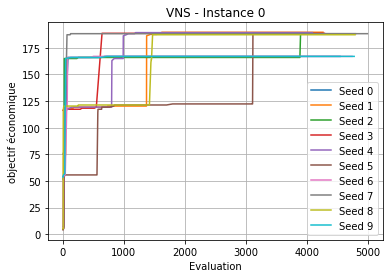

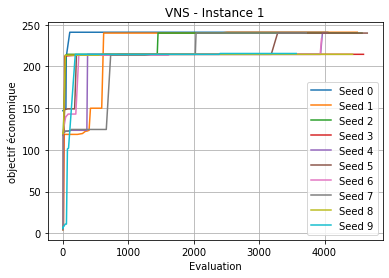

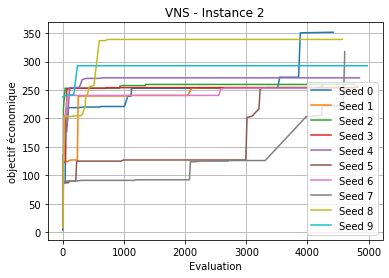

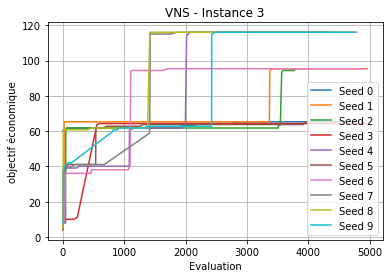

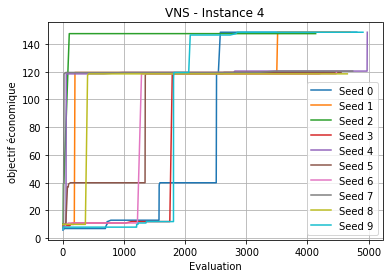

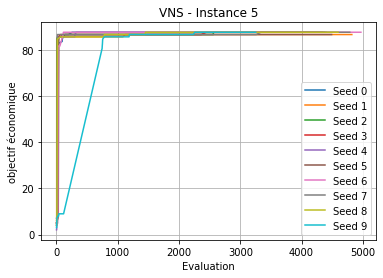

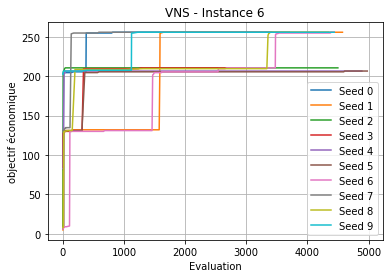

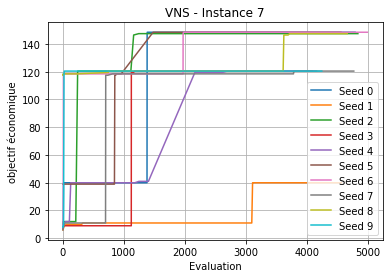

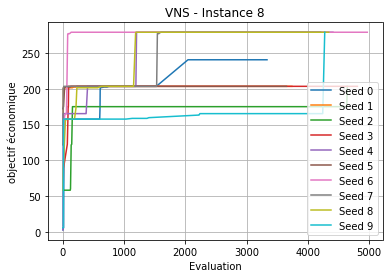

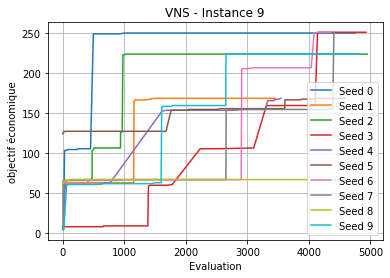

In [180]:
vns_best_list_objectif_economic = [ [] for _ in range(len(instances)) ]
for i in range (len(instances)):
    for j in range(ONE_NB_SEED):
        vns_best_list_objectif_economic[i].append([c.objectives[0] for c in vns_best_list[i][j]])

for i in range (len(instances)):
    for j in range(ONE_NB_SEED):
        y = np.array(vns_best_list_objectif_economic[i][j])
        y = np.maximum.accumulate(y)  # pour avoir le best-so-far
        plt.plot(vns_index_best_list[i][j], y, label=f"Seed {j}")
        
        plt.xlabel("Evaluation")
        plt.ylabel("objectif économique")
        plt.title(f"VNS - Instance {i}")
    plt.grid()
    plt.legend()
    plt.show()

# MLS

In [84]:
# neighborhoods_mls_1 = multipleNeighborhood_alternating(
#     SwapOperationNeighborhood(n=5, nb_job_no_skills=0),
#     MoveSecondWorkerNeighborhood(gen),
#     nb_job_no_skills=0
# )

# neighborhoods_mls_2 = multipleNeighborhood_alternating(
#     MoveOneOperationNeighborhood(),
#     MoveSecondWorkerNeighborhood(gen),
#     nb_job_no_skills=0
# )

In [138]:
ONE_NB_SEED = 5

In [ ]:
mls_times = np.zeros((len(instances), ONE_NB_SEED))
mls_all_viewed = [ [] for _ in range(len(instances)) ]
mls_best_list = [ [] for _ in range(len(instances)) ]
mls_index_best_list = [ [] for _ in range(len(instances)) ]

for i in range(len(instances)):
    print(f"---------- instance {i+1}/{len(instances)} -----------")
    for nb_seed in range(ONE_NB_SEED):
        print(f"MLS - Seed {nb_seed+1}/{ONE_NB_SEED}")

        neighborhood_alternating = multipleNeighborhood_alternating(
            n1=SwapOperationNeighborhood(n=10),
            n2=ChangebaseWorkerNeighborhood(nb_job_no_skills=0, generator=gens[i])
        )

        mls = MultipleLocalSearch(gens[i], evals[i], neighborhood_alternating, sel)
        t = time.time()

        av, bl, indx_bests, best_c = mls.run(MAX_EVAL, patience=100,verbose=False)
        
        mls_times[i, nb_seed] = time.time() - t
        mls_all_viewed[i].append(av)
        mls_best_list[i].append(bl)
        mls_index_best_list[i].append(indx_bests)
        print("best fitness:", best_c.fitness, "best objectives:", best_c.objectives)

VNS - Seed 1/10
best fitness: 16642.06656995338 best objectives: (166.99878177523175, 0.5, -62.81160756979757)
VNS - Seed 2/10
best fitness: 18790.75824020818 best objectives: (188.32636412588232, 1.3412230546351083, -55.29040292640243)
VNS - Seed 3/10
best fitness: 18701.297991767486 best objectives: (187.32636412588232, 1.3412230546351083, -44.75065136709662)
VNS - Seed 4/10
best fitness: 18698.596221925567 best objectives: (187.32636412588232, 1.3412230546351083, -47.4524212090153)
VNS - Seed 5/10
best fitness: 18790.826162336543 best objectives: (188.32636412588232, 1.3412230546351083, -55.222480798036784)
VNS - Seed 6/10
best fitness: 18883.716453001318 best objectives: (189.32636412588232, 1.3412230546351083, -62.33219013326298)
VNS - Seed 7/10
best fitness: 16457.225702078635 best objectives: (164.99878177523175, 0.5, -47.652475444541)
VNS - Seed 8/10
best fitness: 18697.946333769993 best objectives: (187.32636412588232, 1.3412230546351083, -48.10230936459012)
VNS - Seed 9/10
be

In [181]:
mls_best_list_objectif_economic = [ [] for _ in range(len(instances)) ]
for i in range (len(instances)):
    for j in range(ONE_NB_SEED):
        mls_best_list_objectif_economic[i].append([c.objectives[0] for c in mls_best_list[i][j]])

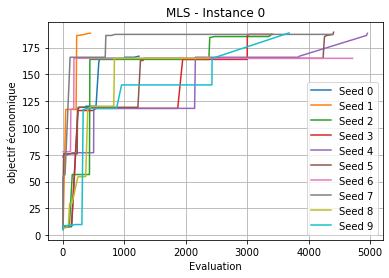

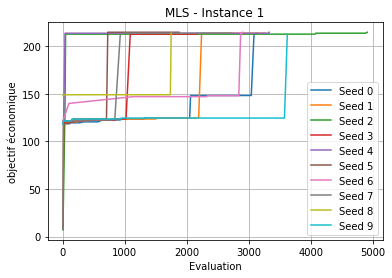

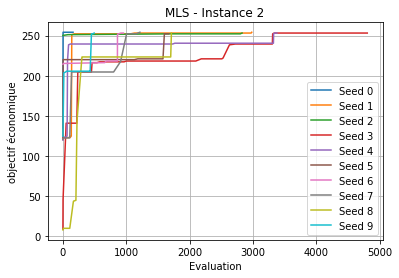

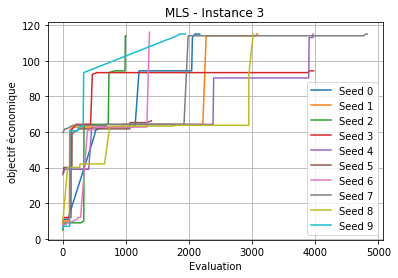

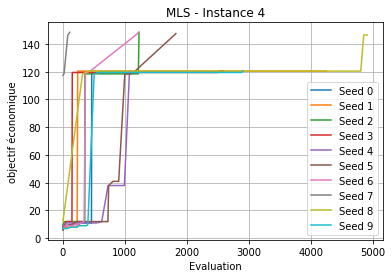

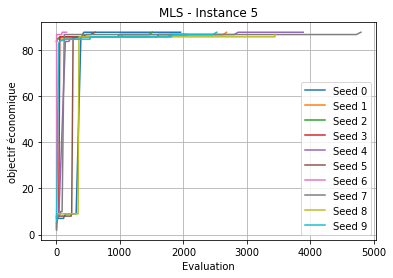

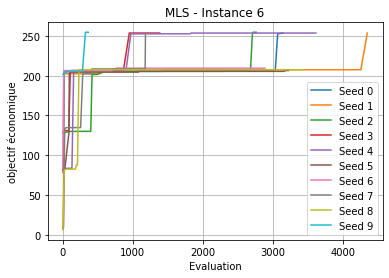

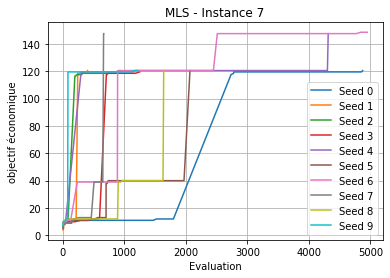

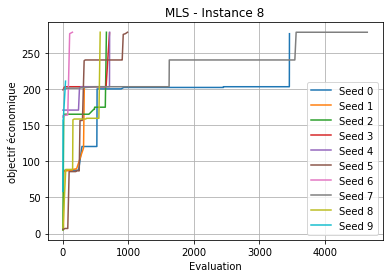

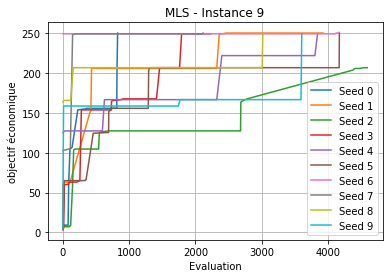

In [182]:
for i in range (len(instances)):
    for j in range(ONE_NB_SEED):
        y = np.array(mls_best_list_objectif_economic[i][j])
        y = np.maximum.accumulate(y)  # pour avoir le best-so-far
        plt.plot(mls_index_best_list[i][j], y, label=f"Seed {j}")
        
        plt.xlabel("Evaluation")
        plt.ylabel("objectif économique")
        plt.title(f"MLS - Instance {i}")
    plt.grid()
    plt.legend()
    plt.show()

In [ ]:
# mean rs 
ONE_NB_SEED = 5
rs_stat = np.zeros((len(instances), ONE_NB_SEED))
for i in range(len(instances)):
    for j in range(ONE_NB_SEED):
        rs_stat[i][j] = rs_best_list_objectif_economic[i][j][-1]
rs_stat = np.array(rs_stat)
rs_stat_mean = np.mean(rs_stat, axis=1)
rs_stat_std = np.std(rs_stat, axis=1)
rs_median = np.median(rs_stat, axis=1)
rs_min = np.min(rs_stat, axis=1)
rs_max = np.max(rs_stat, axis=1)

ONE_NB_SEED = 10

mls_stat = np.zeros((len(instances), ONE_NB_SEED))
for i in range(len(instances)):
    for j in range(ONE_NB_SEED):
        mls_stat[i][j] = mls_best_list_objectif_economic[i][j][-1]
mls_stat = np.array(mls_stat)
mls_stat_mean = np.mean(mls_stat, axis=1)
mls_stat_std = np.std(mls_stat, axis=1)
mls_median = np.median(mls_stat, axis=1)
mls_min = np.min(mls_stat, axis=1)
mls_max = np.max(mls_stat, axis=1)

vns_stat = np.zeros((len(instances), ONE_NB_SEED))
for i in range(len(instances)):
    for j in range(ONE_NB_SEED):
        vns_stat[i][j] = vns_best_c[i][j].objectives[0]
vns_stat = np.array(vns_stat)
vns_stat_mean = np.mean(vns_stat, axis=1)
vns_stat_std = np.std(vns_stat, axis=1)
vns_median = np.median(vns_stat, axis=1)
vns_min = np.min(vns_stat, axis=1)
vns_max = np.max(vns_stat, axis=1)

IndexError: list index out of range

---

---

In [ ]:
for i in range(NB_INSTANCES):
    print("------------------------")
    print("------------------------")
    print("instance :", i)
    profit = s[i].print_objective_values()
    print("cmax=", s[i].C_max)
    print("--")
    print(s_prime[i].print_objective_values())
    print("--$$--")
    print(s[i].compute_objective_values())
    print("--$$--")
    print(s_prime[i].compute_objective_values())


------------------------
------------------------
instance : 0


IndexError: list index out of range

In [ ]:
solution_lexicographic = np.zeros((NB_INSTANCES, 3))
solution_opt_benefit = np.zeros((NB_INSTANCES, 3))
for i in range(NB_INSTANCES):
    solution_lexicographic[i][0] = s[i].compute_objective_values()["0"]
    solution_opt_benefit[i][0] = s_prime[i].compute_objective_values()["0"]

    solution_lexicographic[i][1] = s[i].compute_objective_values()["1"]
    solution_opt_benefit[i][1] = s_prime[i].compute_objective_values()["1"]

    solution_lexicographic[i][2] = s[i].compute_objective_values()["2"]
    solution_opt_benefit[i][2] = s_prime[i].compute_objective_values()["2"]

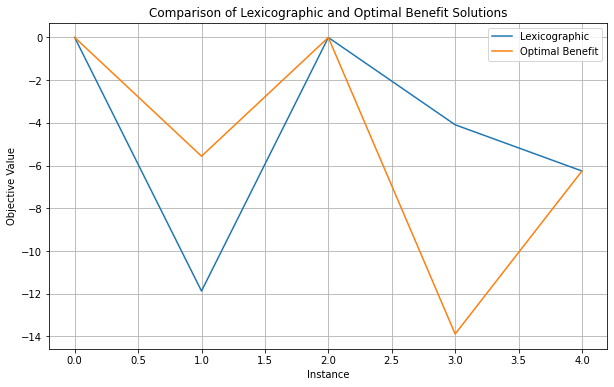

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(solution_lexicographic[:, 2], label="Lexicographic")
plt.plot(solution_opt_benefit[:, 2], label="Optimal Benefit")
plt.xlabel("Instance")
plt.ylabel("Objective Value")
plt.title("Comparison of Lexicographic and Optimal Benefit Solutions")
plt.legend()
plt.grid()
plt.show()

# #Test de validation des solutions MILP

In [161]:
for i in range(NB_INSTANCES):
    row, ok = validate_model_solution(
        instance=instances[i],
        solution=s[i],
        constraints_config=constraints_config,
    )
    print("instance :", i)
    display(pd.DataFrame([row]))

instance : 0


,Nom,C_max,Profit_done,Profit_before_limit,Skill_gain,Cognitive_load,solution_valide,base_worker,solo_no_level_difference,OK
0,solution,20.0,66.156427,0,1.0,0.0,PASS,PASS,PASS,TRUE


instance : 1


,Nom,C_max,Profit_done,Profit_before_limit,Skill_gain,Cognitive_load,solution_valide,base_worker,solo_no_level_difference,OK
0,solution,20.0,92.040339,0,0.806772,11.877247,PASS,PASS,PASS,TRUE


instance : 2


,Nom,C_max,Profit_done,Profit_before_limit,Skill_gain,Cognitive_load,solution_valide,base_worker,solo_no_level_difference,OK
0,solution,20.0,11.203733,0,0.0,0.0,PASS,PASS,PASS,TRUE


instance : 3


,Nom,C_max,Profit_done,Profit_before_limit,Skill_gain,Cognitive_load,solution_valide,base_worker,solo_no_level_difference,OK
0,solution,20.0,229.978168,0,0.5,4.089735,PASS,PASS,PASS,TRUE


instance : 4


,Nom,C_max,Profit_done,Profit_before_limit,Skill_gain,Cognitive_load,solution_valide,base_worker,solo_no_level_difference,OK
0,solution,20.0,153.957216,0,0.5,6.254697,PASS,PASS,PASS,TRUE


---

## Objectives to points

In [165]:
x, y, z = [], [], []
for i in range(NB_INSTANCES):
    x.append(s[i].objective_values[0])
    y.append(s[i].objective_values[1])
    z.append(s[i].objective_values[2])

In [167]:
x, y, z

([72.15642677990554,
  108.04033948228428,
  13.203732727890285,
  242.97816849102978,
  165.9572160677538],
 [1.0, 0.8067722079892947, 0.0, 0.5, 0.5000000000000024],
 [0.0, -11.877246646928636, 0.0, -4.08973453299614, -6.254697259256214])

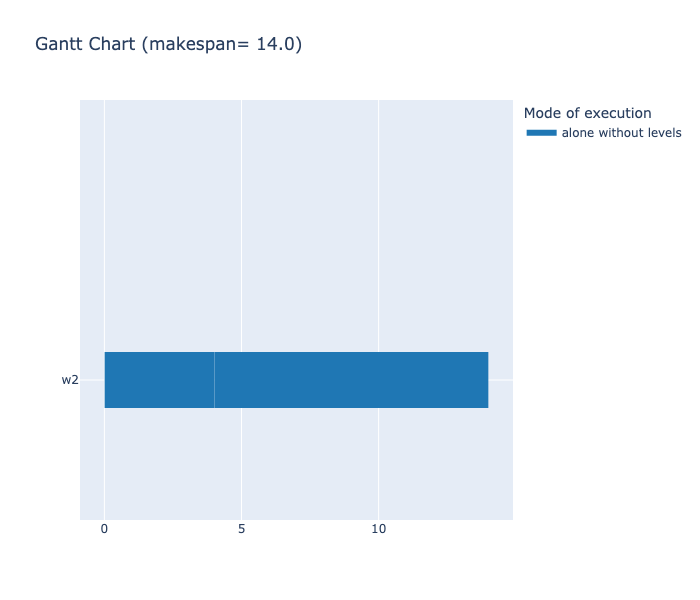

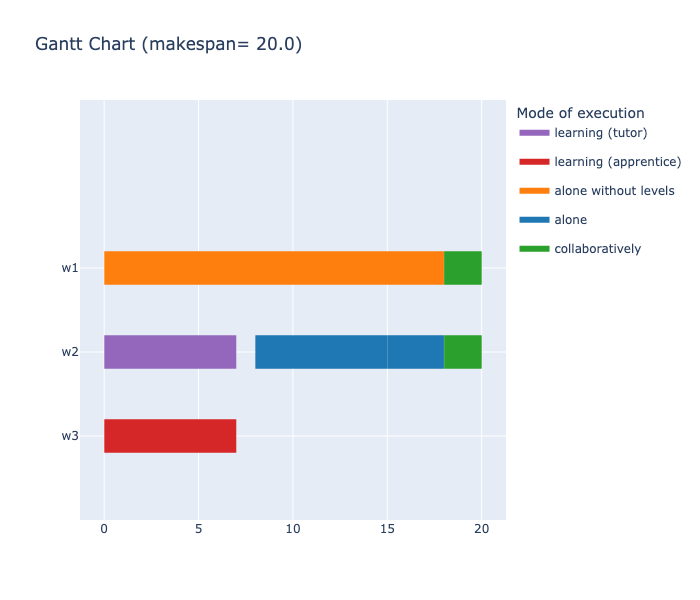

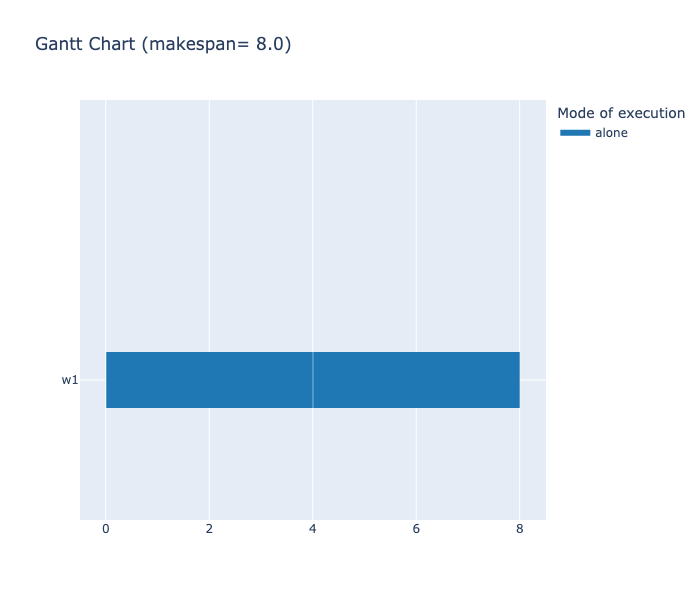

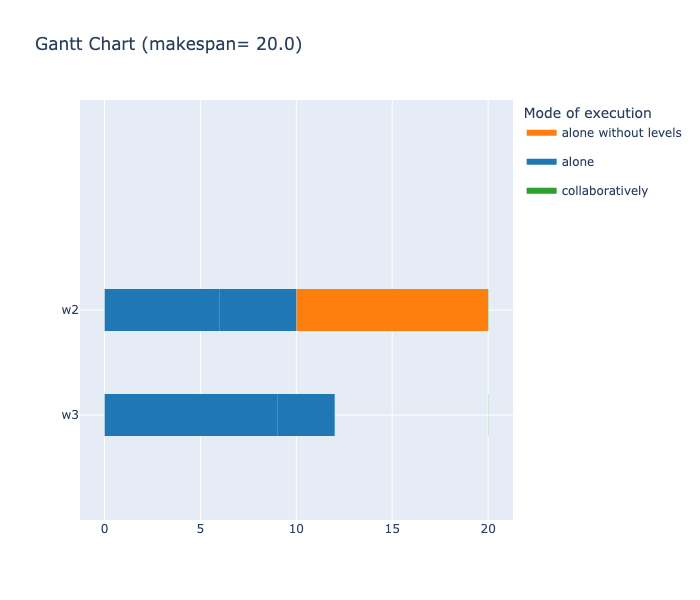

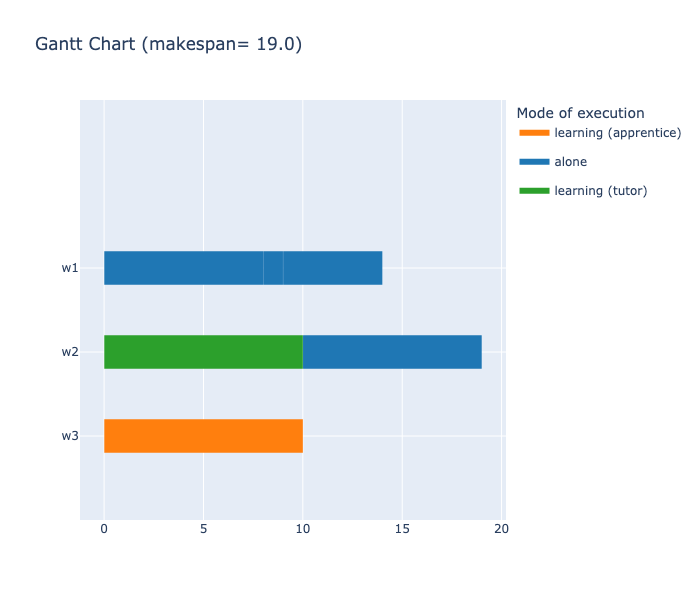

In [163]:
for i in range(NB_INSTANCES):
    gantt_chart(df[i], color=3, render="notebook", separate_little=True)

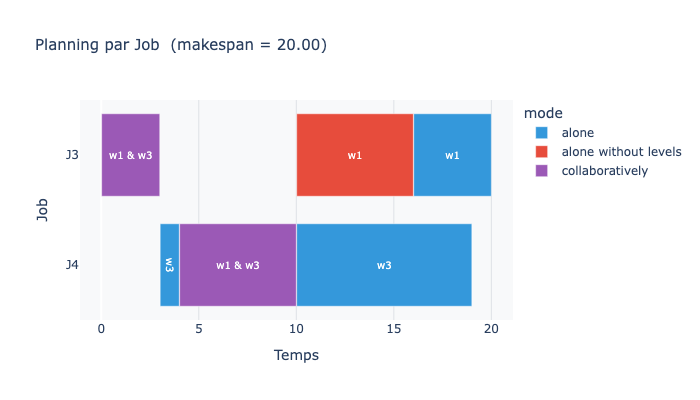

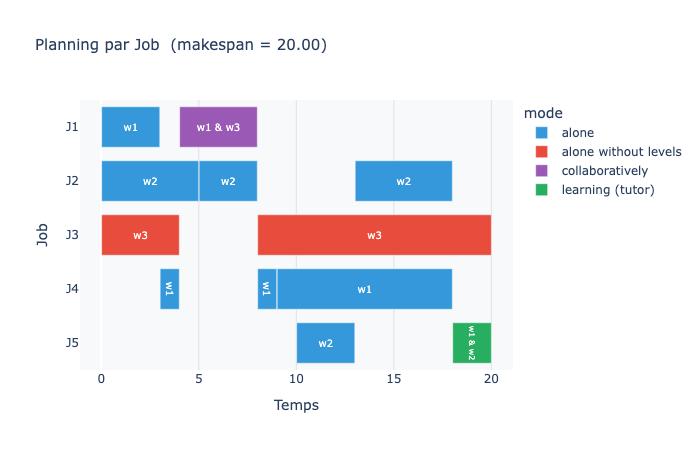

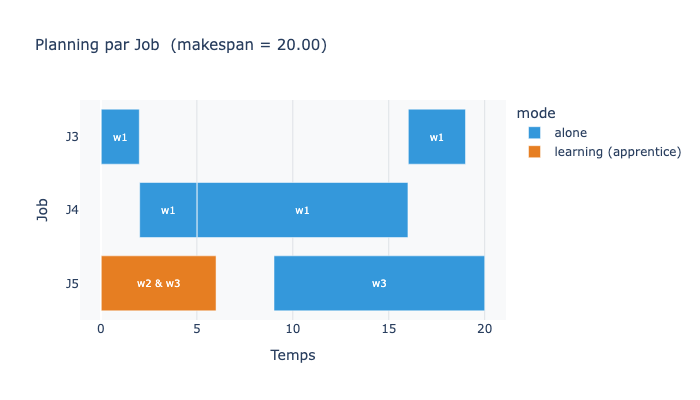

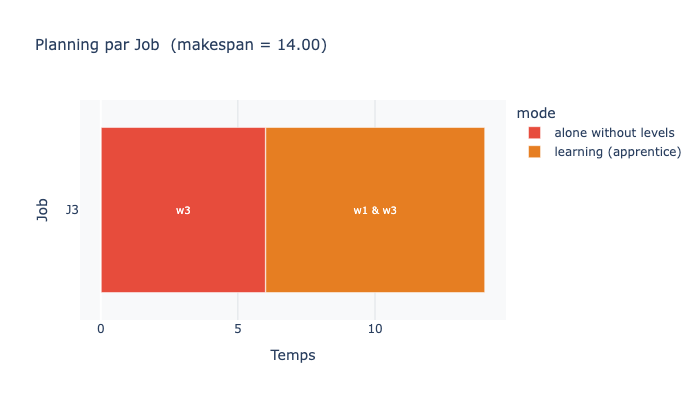

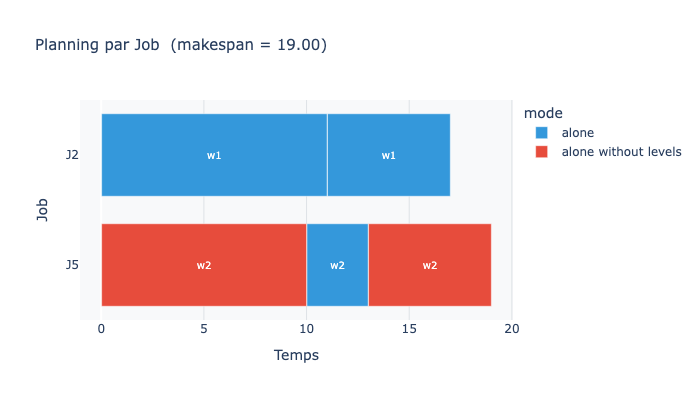

In [561]:
for i in range(NB_INSTANCES):
    gantt_chart_by_job(df[i], instances[i], color_by="mode", render="notebook", save_path=None, separate_little=True)

___

In [81]:
s[0].z_auxilary[2,:,3]

array([0., 0., 0., 0.])

In [82]:
base_worker_milp_solution = np.full((NB_INSTANCES, 2, len(s[0].y)), -1, dtype=int)
for instance_index in range(NB_INSTANCES):
    for i in range (len(s[instance_index].y)):
        for k in range(len(s[instance_index].y[i])):
            if s[instance_index].y[i][k] == 1:
                base_worker_milp_solution[instance_index][0][i] = k
                if np.sum(s[instance_index].z_auxilary[i,:,3]) >= 1:
                    base_worker_milp_solution[instance_index][1][i] = 1
                else:
                    base_worker_milp_solution[instance_index][1][i] = 0

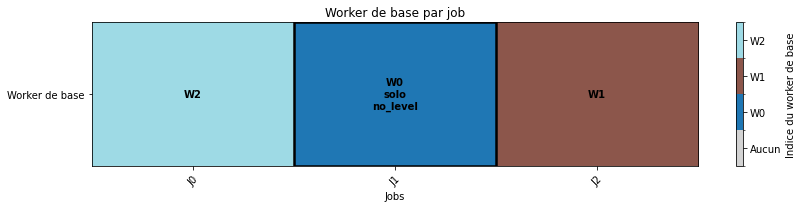

[[2 0 1]
 [0 1 0]]


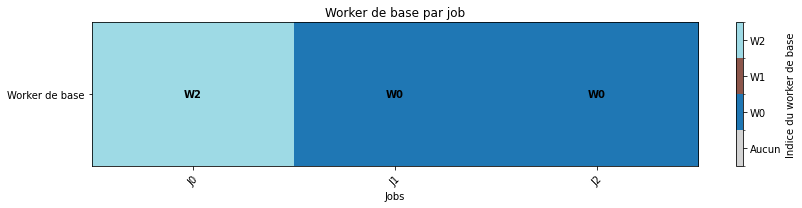

[[2 0 0]
 [0 0 0]]


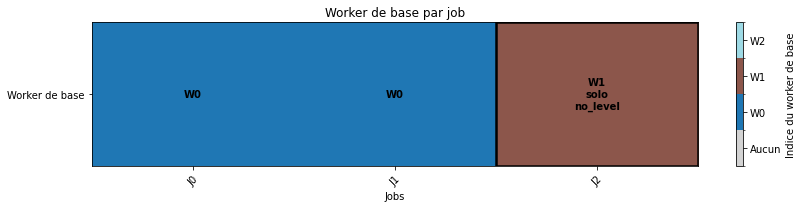

[[0 0 1]
 [0 0 1]]


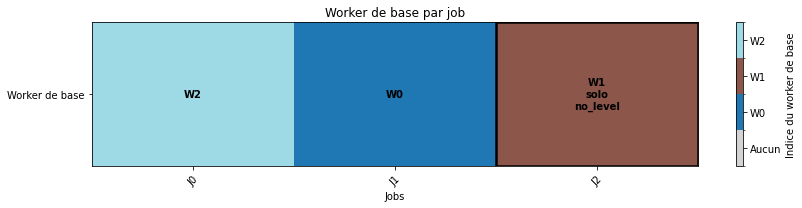

[[2 0 1]
 [0 0 1]]


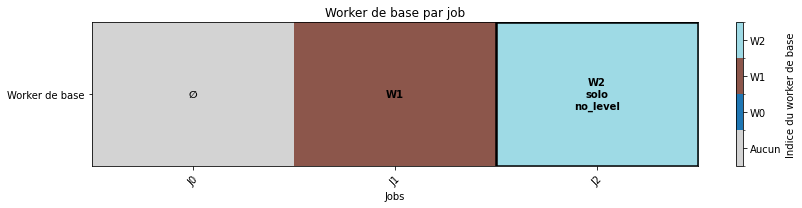

[[-1  1  2]
 [-1  0  1]]


In [83]:
for i in range(NB_INSTANCES):
    visualize_base_worker_heatmap(base_worker_milp_solution[i], nb_workers=instances[i].nb_workers)
    print(base_worker_milp_solution[i])

---

In [84]:
duos = []
for i in range(NB_INSTANCES):
    instance = instances[i]
    duos.append(get_base_worker_operation(base_worker_milp_solution[i], s[i].x, instance))
    plot_jobs_heatmap(duos[i])


# print(duos)

NameError: name 'plot_jobs_heatmap' is not defined

---

In [85]:
for i in range(NB_INSTANCES):
    plot_worker_diff(duos[i], base_worker_milp_solution[i], s[i].x)

NameError: name 'plot_worker_diff' is not defined

# 3. Meta - heuristiques

## 3.2 Local Search

In [86]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm



def plot_jobs_heatmap(mat, title="Différence worker / opération"):
    """
    mat shape: (nb_job, 2, nb_max_operations)

    Valeurs:
      -100 : opération inexistante
      -99  : opération non affectée
      autre: différence entre niveau worker et niveau opération
    """

    nb_job, nb_workers, nb_max_operations = mat.shape

    assert nb_workers == 2, "La deuxième dimension doit être de taille 2"

    # On transforme en matrice 2D :
    # lignes = job0-worker0, job0-worker1, job1-worker0, ...
    H = mat.reshape(nb_job * 2, nb_max_operations)

    special_missing_op = H == -100
    special_not_assigned = H == -99
    valid = ~(special_missing_op | special_not_assigned)

    # Valeurs réelles seulement
    H_valid = H.astype(float)
    H_valid[~valid] = np.nan

    fig, ax = plt.subplots(figsize=(max(8, nb_max_operations * 0.6), max(5, nb_job * 0.5)))

    # Fond blanc pour opérations inexistantes
    background = np.ones((*H.shape, 4))
    background[special_missing_op] = [1, 1, 1, 1]        # blanc
    background[special_not_assigned] = [0.75, 0.75, 0.75, 1]  # gris
    background[valid] = [1, 1, 1, 0]  # transparent pour laisser passer la heatmap

    ax.imshow(background, aspect="auto")


    # # Heatmap des vraies valeurs
    # im = ax.imshow(H_valid, cmap="coolwarm", aspect="auto")


    cmap = plt.get_cmap("RdYlGn").copy()
    cmap.set_bad((1, 1, 1, 0))

    norm = TwoSlopeNorm(vmin=-4, vcenter=0, vmax=4)

    im = ax.imshow(H_valid, cmap=cmap, norm=norm, aspect="auto")

    # Afficher les valeurs dans les cases
    for i in range(H.shape[0]):
        for k in range(H.shape[1]):

            if H[i, k] == -100:
                text = ""          # opération inexistante : rien
            elif H[i, k] == -99:
                text = "NA"        # non affecté
            else:
                text = f"{H[i, k]:.1f}"

            ax.text(
                k, i, text,
                ha="center",
                va="center",
                fontsize=8,
                color="black"
            )

    # Axes
    ax.set_title(title)
    ax.set_xlabel("Opération")
    ax.set_ylabel("Job / Worker")

    ax.set_xticks(np.arange(nb_max_operations))
    ax.set_xticklabels([f"op {i}" for i in range(nb_max_operations)])

    y_labels = []
    for j in range(nb_job):
        y_labels.append(f"job {j} - wi")
        y_labels.append(f"job {j} - wj")

    ax.set_yticks(np.arange(nb_job * 2))
    ax.set_yticklabels(y_labels)

    # Séparateurs entre jobs
    for j in range(1, nb_job):
        ax.axhline(j * 2 - 0.5, color="black", linewidth=1)

    # Grille légère
    ax.set_xticks(np.arange(-0.5, nb_max_operations, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, nb_job * 2, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=0.3)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Colorbar pour les différences valides
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Différence niveau worker - niveau opération")

    # Légende pour les valeurs spéciales
    legend_patches = [
        mpatches.Patch(color="lightgray", label="-99 : non affecté"),
        mpatches.Patch(color="white", label="-100 : opération inexistante"),
    ]
    ax.legend(handles=legend_patches, loc="upper right", bbox_to_anchor=(1.25, 1))

    plt.tight_layout()
    plt.show()

---

In [87]:
constraints_config

{'job_with_no_skills': True,
 'constrained_makespan': False,
 'no_base_worker': False,
 'no_solo_tasks': False}

In [88]:
# constraints_config = {"constrained_makespan": False}

In [89]:
encoding_dicos = []
for i in range (NB_INSTANCES):
    encoding_dicos.append(Encoding_Dicos(instances[i]))


generator = []
for i in range (NB_INSTANCES):
    generator.append(ChromosomeGenerator(instances[i], encoding_dicos[i], config_instances[i]))

decoder = []
for i in range (NB_INSTANCES):
    decoder.append(Decoder(instances[i], encoding_dicos[i], config_instances[i]))

# weights = {
#     "profit" : 100,
#     "skills" : 10,
#     "cognitive_load" : 1
# }

# objective_terms_config = {
#     "benefit_all_jobs": 0,
#     "penalty_levels": 0,
#     "penalty_makespan_job": 0,
#     "Cmax": 1
# }

evaluator = []
for i in range (NB_INSTANCES):
    evaluator.append(Evaluator(decoder[i], weights, objective_terms_config))

selector = BestSelector()

MAX_ITER = 500

In [90]:
neighborhood_BASE_WORKER = []
for i in range (NB_INSTANCES):
    neighborhood_BASE_WORKER.append(ChangebaseWorkerNeighborhood(nb_job_no_skills=1, generator=generator[i]))

neighborhood_SWAP = []
for i in range (NB_INSTANCES):
    neighborhood_SWAP.append(SwapOperationNeighborhood(3))

multiple_neighborhood_cumulative = []
multiple_neighborhood_alternating = []
for i in range(NB_INSTANCES):
    multiple_neighborhood_cumulative.append(multipleNeighborhood_cumulative(neighborhood_BASE_WORKER[i], neighborhood_SWAP[i]))
    multiple_neighborhood_alternating.append(multipleNeighborhood_alternating(neighborhood_BASE_WORKER[i], neighborhood_SWAP[i]))

In [108]:
""""
local_search_base_worker = LocalSearch(
    generator, 
    evaluator,
    neighborhood_BASE_WORKER,
    selector,
    )

local_search_swap = LocalSearch(
    generator, 
    evaluator,
    neighborhood_SWAP,
    selector,
    )

local_search_cumulative = LocalSearch(
    generator, 
    evaluator,
    multiple_neighborhood_cumulative,
    selector,
    )

local_search_alternating = LocalSearch(
    generator, 
    evaluator,
    multiple_neighborhood_alternating,
    selector,
    )

NB_SEED = 10
"""

local_search_base_worker = []
local_search_swap = []
local_search_cumulative = []
local_search_alternating = []

for i in range(NB_INSTANCES):
    local_search_base_worker.append(
        LocalSearch(
            generator[i],
            evaluator[i],
            neighborhood_BASE_WORKER[i],
            selector,
        )
    )

    local_search_swap.append(
        LocalSearch(
            generator[i],
            evaluator[i],
            neighborhood_SWAP[i],
            selector,
        )
    )

    local_search_cumulative.append(
        LocalSearch(
            generator[i],
            evaluator[i],
            multiple_neighborhood_cumulative[i],
            selector,
        )
    )

    local_search_alternating.append(
        LocalSearch(
            generator[i],
            evaluator[i],
            multiple_neighborhood_alternating[i],
            selector,
        )
    )



In [124]:
NB_SEED = 10
# =====================================================
# Stockage des chromosomes
# Structure :
# multiple_all_list_base_worker[instance_id][seed_id][iteration] = chromosome
# multiple_best_list_base_worker[instance_id][seed_id][iteration] = meilleur chromosome courant
# =====================================================

multiple_all_list_base_worker = []
multiple_all_list_swap = []
multiple_all_list_cumulative = []
multiple_all_list_alternating = []

multiple_best_list_base_worker = []
multiple_best_list_swap = []
multiple_best_list_cumulative = []
multiple_best_list_alternating = []

# =====================================================
# Stockage des fitness uniquement pour les graphiques
# Structure :
# multiple_fitness_base_worker[instance_id][seed_id][iteration] = fitness
# =====================================================

multiple_fitness_base_worker = []
multiple_fitness_swap = []
multiple_fitness_cumulative = []
multiple_fitness_alternating = []

for inst_id in range(NB_INSTANCES):
    print(f"\n========== Instance {inst_id} ==========")

    instance_all_base_worker = []
    instance_all_swap = []
    instance_all_cumulative = []
    instance_all_alternating = []

    instance_best_base_worker = []
    instance_best_swap = []
    instance_best_cumulative = []
    instance_best_alternating = []

    instance_fitness_base_worker = []
    instance_fitness_swap = []
    instance_fitness_cumulative = []
    instance_fitness_alternating = []

    for seed_id in range(NB_SEED):
        print(f"Seed {seed_id + 1}/{NB_SEED}")

        # =========================
        # Base worker
        # =========================
        all_list, best_list = local_search_base_worker[inst_id].run(MAX_ITER, verbose=False)

        instance_all_base_worker.append(all_list)
        instance_best_base_worker.append(best_list)
        instance_fitness_base_worker.append([sol.fitness for sol in all_list])

        # =========================
        # Swap
        # =========================
        all_list, best_list = local_search_swap[inst_id].run(MAX_ITER, verbose=False)

        instance_all_swap.append(all_list)
        instance_best_swap.append(best_list)
        instance_fitness_swap.append([sol.fitness for sol in all_list])

        # =========================
        # Cumulative
        # =========================
        all_list, best_list = local_search_cumulative[inst_id].run(MAX_ITER, verbose=False)

        instance_all_cumulative.append(all_list)
        instance_best_cumulative.append(best_list)
        instance_fitness_cumulative.append([sol.fitness for sol in all_list])

        # =========================
        # Alternating
        # =========================
        all_list, best_list = local_search_alternating[inst_id].run(MAX_ITER, verbose=False)

        instance_all_alternating.append(all_list)
        instance_best_alternating.append(best_list)
        instance_fitness_alternating.append([sol.fitness for sol in all_list])

    # =========================
    # Sauvegarde chromosomes
    # =========================
    multiple_all_list_base_worker.append(instance_all_base_worker)
    multiple_all_list_swap.append(instance_all_swap)
    multiple_all_list_cumulative.append(instance_all_cumulative)
    multiple_all_list_alternating.append(instance_all_alternating)

    multiple_best_list_base_worker.append(instance_best_base_worker)
    multiple_best_list_swap.append(instance_best_swap)
    multiple_best_list_cumulative.append(instance_best_cumulative)
    multiple_best_list_alternating.append(instance_best_alternating)

    # =========================
    # Sauvegarde fitness pour les graphes
    # =========================
    multiple_fitness_base_worker.append(np.array(instance_fitness_base_worker))
    multiple_fitness_swap.append(np.array(instance_fitness_swap))
    multiple_fitness_cumulative.append(np.array(instance_fitness_cumulative))
    multiple_fitness_alternating.append(np.array(instance_fitness_alternating))


========== Instance 0 ==========
Seed 1/10
classify_jobs_with_base_worker= [[[1, 2], []], [[0, 1, 2], []], [[1, 2], []]]
base_worker_assignment= [[2 0 1]
 [0 0 0]]
chromosome :  osc :
[1, 1, 2, 2, 0, 0]
fwac:
[2 2 1 1 1 1]
swac:
[-1  1  0  0  2 -1]

classify_jobs_with_base_worker= [[[1, 2], []], [[0, 1, 2], []], [[1, 2], []]]
base_worker_assignment= [[2 2 1]
 [0 0 0]]
chromosome :  osc :
[0, 0, 2, 2, 1, 1]
fwac:
[2 2 2 2 1 1]
swac:
[ 1  1 -1  0  2 -1]

classify_jobs_with_base_worker= [[[1, 2], []], [[0, 1, 2], []], [[1, 2], []]]
base_worker_assignment= [[1 0 1]
 [0 0 0]]
chromosome :  osc :
[0, 0, 2, 2, 1, 1]
fwac:
[1 1 0 1 1 1]
swac:
[-1 -1 -1  0  2  2]

classify_jobs_with_base_worker= [[[1, 2], []], [[0, 1, 2], []], [[1, 2], []]]
base_worker_assignment= [[2 1 1]
 [0 0 0]]
chromosome :  osc :
[0, 0, 2, 2, 1, 1]
fwac:
[2 2 1 1 1 1]
swac:
[ 1  1  2 -1  2  2]

Seed 2/10
classify_jobs_with_base_worker= [[[1, 2], []], [[0, 1, 2], []], [[1, 2], []]]
base_worker_assignment= [[1 2 1]
 [0 0 0

In [125]:
print(instances[4])


 ===== Start of Instance: =====
Number of jobs: 3
Number of professions: 1
Number of tasks per profession: [13]
Max number of operations per Jobs: 4
Total number of tasks: 13
Total number of workers: 3
Task to profession mapping:
{0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 0, 12: 0}
Worker levels: shape=(3, 1)
 [[2.71270012]
 [3.83876722]
 [3.1140365 ]]
Job difficulties: shape= (3,)
[4. 3. 4.]
Job resale prices: shape= (3,)
[ 40.85525544  40.79781096 144.11628654]
Task difficulties: shape= (13,)
[3. 3. 4. 4. 3. 4. 3. 4. 2. 3. 3. 1. 4.]
Task processing times: shape= (13, 3)
[[ 2  4 -1]
 [ 6  9  4]
 [ 5 11  2]
 [ 7 13  4]
 [ 3  7  1]
 [ 4  9 -1]
 [ 3  5  2]
 [ 6 10  3]
 [ 5 10  2]
 [ 4  5  2]
 [ 1  2 -1]
 [11 21 -1]
 [ 6 12 -1]]
Jobs structure: len= 3
Job 0 : 	O_(0,0) = 2 	O_(0,1) = 10 
Job 1 : 	O_(1,0) = 4 	O_(1,1) = 1 
Job 2 : 	O_(2,0) = 12 	O_(2,1) = 12 	O_(2,2) = 5 


 ===== End of Instance: =====



## #Tests solution réalisable

Tester si tout les runs finissent avec une solution réalisable.

In [126]:


neighborhoods = {
    "Base Worker":  multiple_best_list_base_worker,
    "Swap":         multiple_best_list_swap,
    "Cumulative":   multiple_best_list_cumulative,
    "Alternating":  multiple_best_list_alternating,
}

df_val, summary = validate_best_chromosomes(
    neighborhoods=neighborhoods,
    instances=instances,
    encoding_dicos=encoding_dicos,
    generators=generator,
    decoders=decoder,
    evaluators=evaluator,
    nb_instances=NB_INSTANCES,
    nb_seed=NB_SEED,
    position=-1,
)

display(df_val)
print_validation_summary(summary)

,Instance,Seed,Voisinage,Fitness,osc_occurrences,osc_length,fwac_swac_range,no_same_worker,base_worker_shape,base_worker_covers_all,nb_no_level_jobs,no_two_unqualified,teaching_diff,solo_no_level_diff,solution_checker,fitness_coherente,job_done_coherent,OK
0,I0,0,Base Worker,11237.71,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,TRUE
1,I0,1,Base Worker,11237.71,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,TRUE
2,I0,2,Base Worker,11237.71,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,TRUE
3,I0,3,Base Worker,11237.71,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,TRUE
4,I0,4,Base Worker,11237.71,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,TRUE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,I4,5,Alternating,18467.03,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,TRUE
196,I4,6,Alternating,8157.06,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,TRUE
197,I4,7,Alternating,18459.27,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,TRUE
198,I4,8,Alternating,18467.03,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,TRUE



TOUS LES TESTS PASSENT
200/200 solution(s) valide(s)


In [127]:
df_val[df_val["OK"] == "FALSE"]

,Instance,Seed,Voisinage,Fitness,osc_occurrences,osc_length,fwac_swac_range,no_same_worker,base_worker_shape,base_worker_covers_all,nb_no_level_jobs,no_two_unqualified,teaching_diff,solo_no_level_diff,solution_checker,fitness_coherente,job_done_coherent,OK


In [128]:
best_list[0].base_worker_assignment.shape

(2, 3)

In [129]:
def plot_base_workers_selected(chromosomes):
    """
    Montre l'évolution des workers de bases des jobs au cours des itération du meilleur chromosome courant

    Hypothèse :
    - base_worker_assignment[0][j] = indice du worker de base du job j
    - base_worker_assignment[1][j] = 1 si solo no level, 0 sinon
    """

    if len(chromosomes) == 0:
        print("Liste de chromosomes vide.")
        return

    n_jobs = chromosomes[0].base_worker_assignment.shape[1]

    # Petit décalage vertical pour éviter que les courbes se cachent en se superposant
    if n_jobs == 1:
        offsets = np.array([0.0])
    else:
        step = min(0.12, 0.45 / n_jobs)
        offsets = (np.arange(n_jobs) - (n_jobs - 1) / 2) * step

    plt.figure(figsize=(11, 5))

    all_real_workers = []

    for job_id in range(n_jobs):
        x_values = []
        y_values = []

        solo_x = []
        solo_y = []

        for c_idx, ch in enumerate(chromosomes):

            worker_id = ch.base_worker_assignment[0][job_id]

            # Si -1 signifie "pas de worker de base", on ignore
            if worker_id == -1:
                continue

            all_real_workers.append(worker_id)

            # Décalage seulement pour l'affichage
            y_display = worker_id + offsets[job_id]

            x_values.append(c_idx)
            y_values.append(y_display)

            if ch.base_worker_assignment[1][job_id] == 1: #solo no level
                solo_x.append(c_idx)
                solo_y.append(y_display)

        if len(x_values) == 0:
            continue

        plt.plot(
            x_values,
            y_values,
            marker="o",
            linewidth=1.5,
            alpha=0.8,
            label=f"Job {job_id}"
        )

        # Marque spéciale pour solo no level
        if len(solo_x) > 0:
            plt.scatter(
                solo_x,
                solo_y,
                marker="x",
                s=90,
                linewidths=2
            )

    if len(all_real_workers) == 0:
        print("Aucun worker de base détecté.")
        return

    unique_workers = sorted(set(all_real_workers))

    plt.yticks(
        unique_workers,
        [f"W{w}" for w in unique_workers]
    )

    plt.xlabel("Chromosome")
    plt.ylabel("Worker de base sélectionné")
    plt.title(f"Workers affectés comme workers de base par job ({n_jobs} jobs)")
    plt.grid(True)

    plt.legend(
        title="Jobs",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

In [130]:
best_list[0].base_worker_assignment

array([[-1,  1,  1],
       [ 0,  0,  1]])

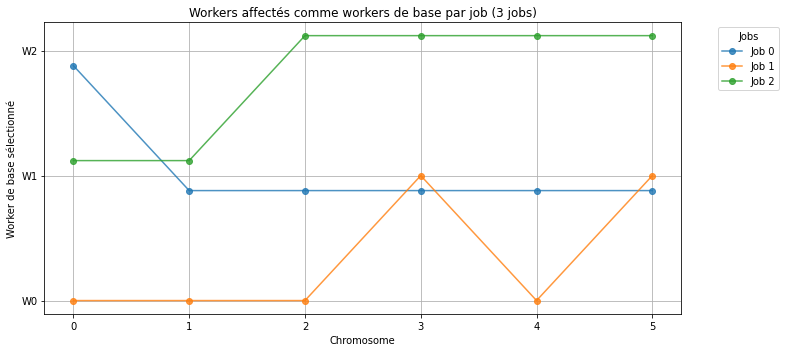

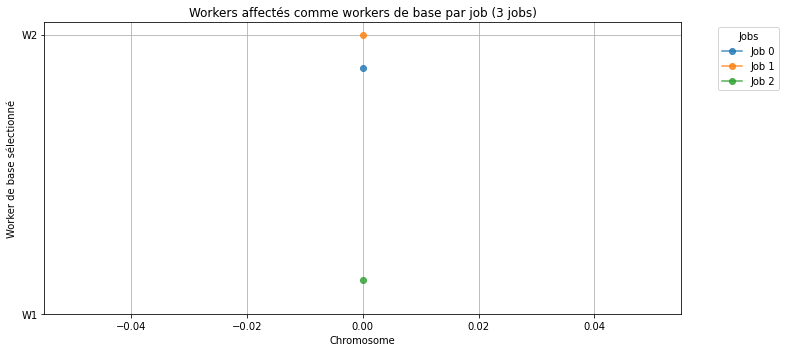

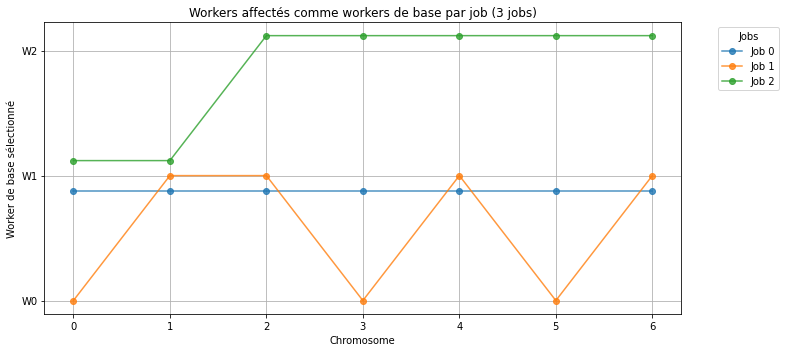

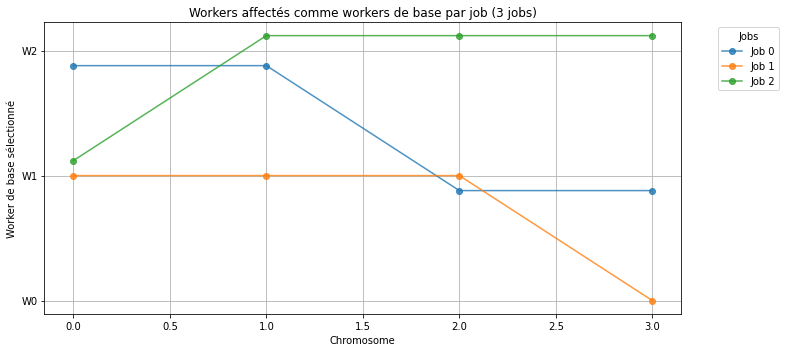

In [132]:
# plot_base_workers_selected(multiple_best_list_base_worker[0][0])
plot_base_workers_selected(multiple_best_list_base_worker[0][0])
plot_base_workers_selected(multiple_best_list_swap[0][0])
plot_base_workers_selected(multiple_best_list_cumulative[0][0])
plot_base_workers_selected(multiple_best_list_alternating[0][0])

In [133]:
fitness_exacte_by_instance = []

for inst_id in range(NB_INSTANCES):
    fitness_exacte = (
        s[inst_id].resale_price_job_done() * weights["profit"]
        + s[inst_id].sum_skill_levels_rate() * weights["skills"]
        - s[inst_id].sum_cognitive_load_total() * weights["cognitive_load"]
        - s[inst_id].C_max
    )
    fitness_exacte_by_instance.append(fitness_exacte)

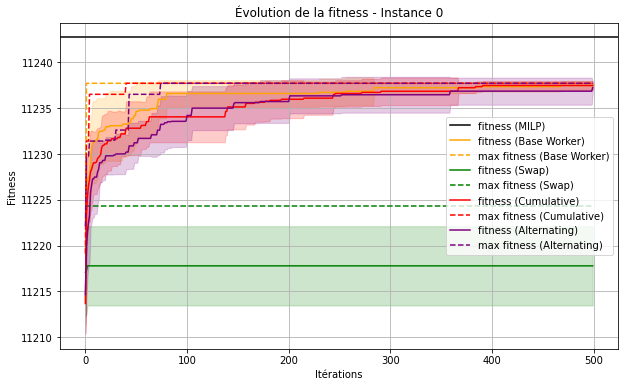

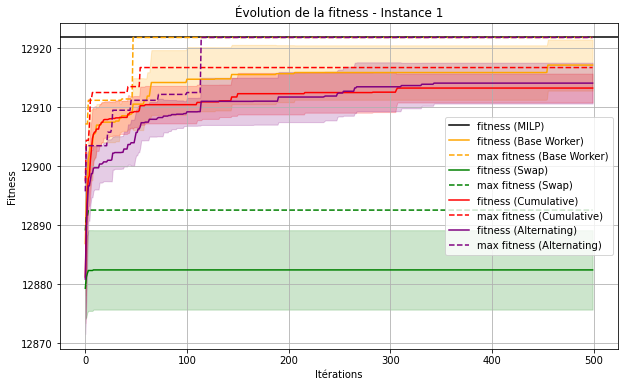

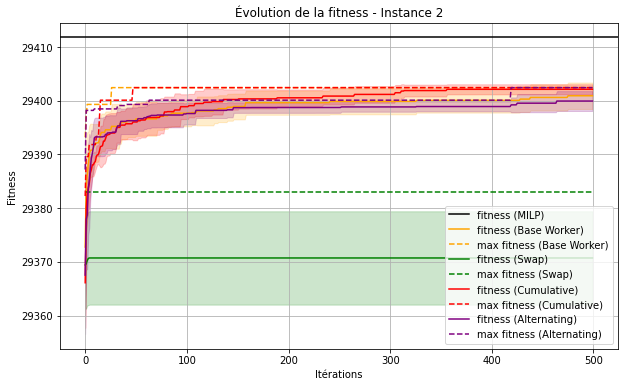

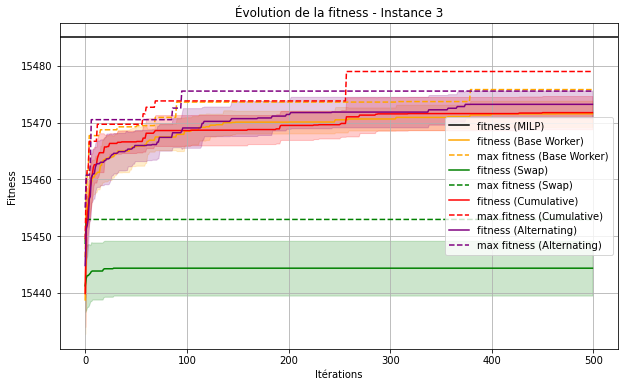

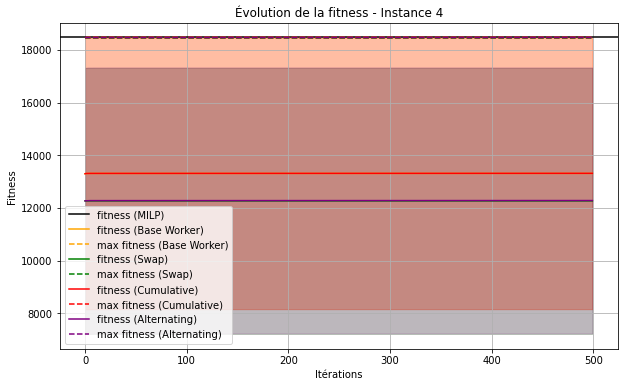

In [134]:
for inst_id in range(NB_INSTANCES):

    # Récupération des résultats de l'instance courante
    arr_base_worker = multiple_fitness_base_worker[inst_id]
    arr_swap = multiple_fitness_swap[inst_id]
    arr_cumulative = multiple_fitness_cumulative[inst_id]
    arr_alternating = multiple_fitness_alternating[inst_id]

    # Moyennes et écarts-types sur les seeds
    mean_base_worker = np.mean(arr_base_worker, axis=0)
    std_base_worker = np.std(arr_base_worker, axis=0)
    max_base_worker = np.max(arr_base_worker, axis=0)
    min_base_worker = np.min(arr_base_worker, axis=0)

    mean_swap = np.mean(arr_swap, axis=0)
    std_swap = np.std(arr_swap, axis=0)
    max_swap = np.max(arr_swap, axis=0)
    min_swap = np.min(arr_swap, axis=0)

    mean_cumulative = np.mean(arr_cumulative, axis=0)
    std_cumulative = np.std(arr_cumulative, axis=0)
    max_cumulative = np.max(arr_cumulative, axis=0)
    min_cumulative = np.min(arr_cumulative, axis=0)

    mean_alternating = np.mean(arr_alternating, axis=0)
    std_alternating = np.std(arr_alternating, axis=0)
    max_alternating = np.max(arr_alternating, axis=0)
    min_alternating = np.min(arr_alternating, axis=0)

    # Axe des itérations
    x_axis = range(len(mean_base_worker))

    plt.figure(figsize=(10, 6))

    # tracer la ligne horizontale représentant la solution MILP
    plt.axhline(y=fitness_exacte_by_instance[inst_id], color='black', label='fitness (MILP)')

    plt.plot(mean_base_worker, label='fitness (Base Worker)', color='orange')
    plt.fill_between(
        x_axis,
        mean_base_worker - std_base_worker,
        mean_base_worker + std_base_worker,
        color='orange',
        alpha=0.2
    )
    plt.plot(max_base_worker, label='max fitness (Base Worker)', color='orange', linestyle='dashed')

    plt.plot(mean_swap, label='fitness (Swap)', color='green')
    plt.fill_between(
        x_axis,
        mean_swap - std_swap,
        mean_swap + std_swap,
        color='green',
        alpha=0.2
    )
    plt.plot(max_swap, label='max fitness (Swap)', color='green', linestyle='dashed')

    plt.plot(mean_cumulative, label='fitness (Cumulative)', color='red')
    plt.fill_between(
        x_axis,
        mean_cumulative - std_cumulative,
        mean_cumulative + std_cumulative,
        color='red',
        alpha=0.2
    )
    plt.plot(max_cumulative, label='max fitness (Cumulative)', color='red', linestyle='dashed')

    plt.plot(mean_alternating, label='fitness (Alternating)', color='purple')
    plt.fill_between(
        x_axis,
        mean_alternating - std_alternating,
        mean_alternating + std_alternating,
        color='purple',
        alpha=0.2
    )
    plt.plot(max_alternating, label='max fitness (Alternating)', color='purple', linestyle='dashed')

    plt.title(f"Évolution de la fitness - Instance {inst_id}")
    plt.xlabel("Itérations")
    plt.ylabel("Fitness")
    plt.legend()
    plt.grid()
    plt.show()

In [494]:
# multiple_all_list_base_worker = []

# for i in range(NB_SEED):
#     all_list, best_list =local_search_base_worker.run(MAX_ITER, verbose=False)
#     multiple_all_list_base_worker.append(all_list)

In [495]:
# multiple_all_list_swap = []

# for i in range(NB_SEED):
#     all_list, best_list =local_search_swap.run(MAX_ITER, verbose=False)
#     multiple_all_list_swap.append(all_list)

In [496]:
# multiple_all_list_cumulative = []

# for i in range(NB_SEED):
#     all_list, best_list =local_search_cumulative.run(MAX_ITER, verbose=False)
#     multiple_all_list_cumulative.append(all_list)

In [497]:
# multiple_all_list_alternating = []

# for i in range(NB_SEED):
#     all_list, best_list =local_search_alternating.run(MAX_ITER, verbose=False)
#     multiple_all_list_alternating.append(all_list)

---

In [498]:
# for i in range(NB_SEED):
#     for j in range(len(multiple_all_list_base_worker[i])):
#         multiple_all_list_base_worker[i][j] = multiple_all_list_base_worker[i][j].fitness
#         multiple_all_list_swap[i][j] = multiple_all_list_swap[i][j].fitness
#         multiple_all_list_cumulative[i][j] = multiple_all_list_cumulative[i][j].fitness
#         multiple_all_list_alternating[i][j] = multiple_all_list_alternating[i][j].fitness

In [499]:
# multiple_all_list_base_worker = np.array(multiple_all_list_base_worker)
# mean_multiple_all_list_base_worker = np.mean(multiple_all_list_base_worker, axis=0)
# std_multiple_all_list_base_worker = np.std(multiple_all_list_base_worker, axis=0)

# multiple_all_list_swap = np.array(multiple_all_list_swap)
# mean_multiple_all_list_swap = np.mean(multiple_all_list_swap, axis=0)
# std_multiple_all_list_swap = np.std(multiple_all_list_swap, axis=0)

# multiple_all_list_cumulative = np.array(multiple_all_list_cumulative)
# mean_multiple_all_list_cumulative = np.mean(multiple_all_list_cumulative, axis=0)
# std_multiple_all_list_cumulative = np.std(multiple_all_list_cumulative, axis=0)

# multiple_all_list_alternating = np.array(multiple_all_list_alternating)
# mean_multiple_all_list_alternating = np.mean(multiple_all_list_alternating, axis=0)
# std_multiple_all_list_alternating = np.std(multiple_all_list_alternating, axis=0)

In [500]:
# plt.figure(figsize=(10, 6))

# plt.plot(mean_multiple_all_list_base_worker, label='fitness (Base Worker)', color='orange')
# plt.fill_between(range(len(mean_multiple_all_list_base_worker)), mean_multiple_all_list_base_worker - std_multiple_all_list_base_worker, mean_multiple_all_list_base_worker + std_multiple_all_list_base_worker, color='orange', alpha=0.2)

# plt.plot(mean_multiple_all_list_swap, label='fitness (Swap)', color='green')
# plt.fill_between(range(len(mean_multiple_all_list_swap)), mean_multiple_all_list_swap - std_multiple_all_list_swap, mean_multiple_all_list_swap + std_multiple_all_list_swap, color='green', alpha=0.2)

# plt.plot(mean_multiple_all_list_cumulative, label='fitness (Cumulative)', color='red')
# plt.fill_between(range(len(mean_multiple_all_list_cumulative)), mean_multiple_all_list_cumulative - std_multiple_all_list_cumulative, mean_multiple_all_list_cumulative + std_multiple_all_list_cumulative, color='red', alpha=0.2)

# plt.plot(mean_multiple_all_list_alternating, label='fitness (Alternating)', color='purple')
# plt.fill_between(range(len(mean_multiple_all_list_alternating)), mean_multiple_all_list_alternating - std_multiple_all_list_alternating, mean_multiple_all_list_alternating + std_multiple_all_list_alternating, color='purple', alpha=0.2)

# plt.title('Évolution de la fitness au cours des itérations')
# plt.xlabel('Itérations')
# plt.ylabel('Fitness')
# plt.legend()
# plt.grid()
# plt.show()

In [605]:
np.max(arr_base_worker)

18875.400750536595

In [618]:
multiple_all_list_base_worker[0][:,-1]

array([33236.49300727, 33236.49300727, 33236.49300727, 33236.49300727,
       33236.49300727, 33236.49300727, 33236.49300727, 33236.49300727,
       33236.49300727, 33236.49300727])

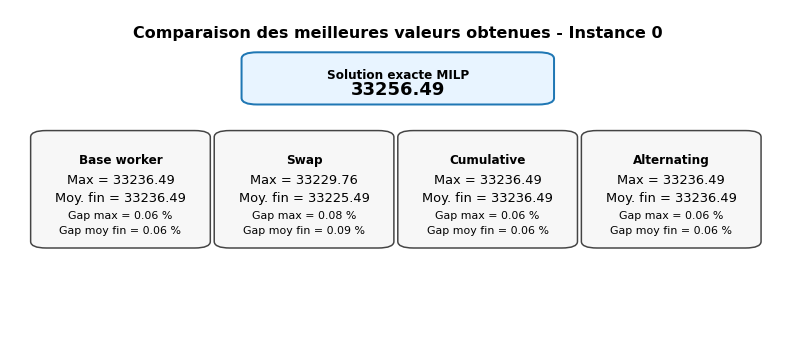

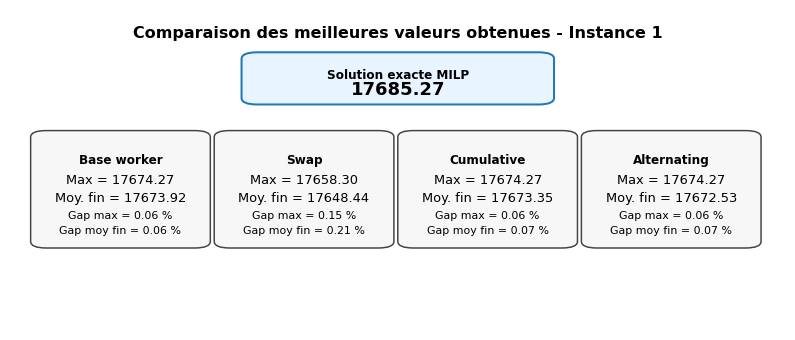

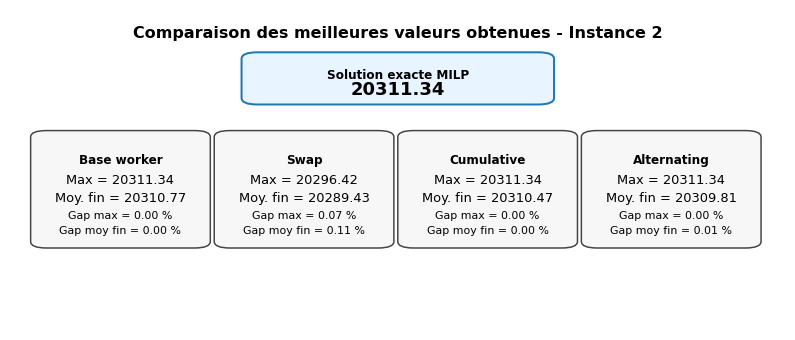

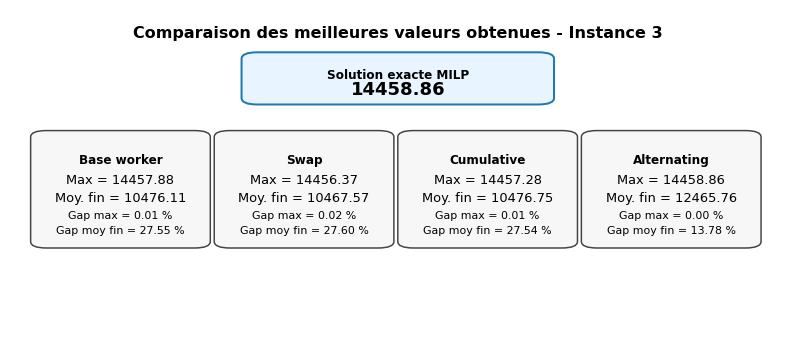

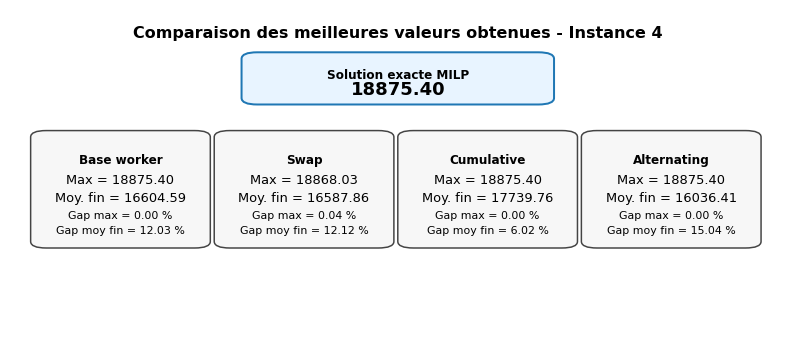

In [ ]:
"""
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# =========================
# VALEUR EXACTE MILP
# =========================
fitness_exacte = profit*100 + skills*10 - cognitive_load*1- s.C_max

# =========================
# CONVERSION
# =========================
multiple_all_list_base_worker = np.array(multiple_all_list_base_worker)
multiple_all_list_swap = np.array(multiple_all_list_swap)
multiple_all_list_cumulative = np.array(multiple_all_list_cumulative)
multiple_all_list_alternating = np.array(multiple_all_list_alternating)

# =========================
# MAX GLOBAL TROUVÉ
# =========================
max_base_worker = np.max(multiple_all_list_base_worker)
max_swap = np.max(multiple_all_list_swap)
max_cumulative = np.max(multiple_all_list_cumulative)
max_alternating = np.max(multiple_all_list_alternating)

results = [
    ("Base worker", max_base_worker),
    ("Swap", max_swap),
    ("Cumulative", max_cumulative),
    ("Alternating", max_alternating),
]

# =========================
# IMAGE TYPE CARTES
# =========================
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")

# Titre
ax.text(
    0.5, 0.92,
    "Comparaison des meilleures valeurs obtenues avec la solution exacte",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

# Carte solution exacte
box = FancyBboxPatch(
    (0.32, 0.72),
    0.36,
    0.12,
    boxstyle="round,pad=0.02",
    linewidth=2,
    facecolor="#E8F4FF",
    edgecolor="#1F77B4"
)
ax.add_patch(box)

ax.text(
    0.5, 0.79,
    "Solution exacte MILP",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold"
)

ax.text(
    0.5, 0.745,
    f"{fitness_exacte:.2f}",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold"
)

# Cartes méthodes
x_positions = [0.05, 0.285, 0.52, 0.755]
y = 0.35
width = 0.19
height = 0.25

for x, (name, value) in zip(x_positions, results):

    gap = 100 * (fitness_exacte - value) / abs(fitness_exacte)

    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.02",
        linewidth=1.5,
        facecolor="#F7F7F7",
        edgecolor="#444444"
    )
    ax.add_patch(box)

    ax.text(
        x + width / 2,
        y + 0.18,
        name,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

    ax.text(
        x + width / 2,
        y + 0.115,
        f"Max = {value:.2f}",
        ha="center",
        va="center",
        fontsize=14
    )

    ax.text(
        x + width / 2,
        y + 0.06,
        f"Gap = {gap:.2f} %",
        ha="center",
        va="center",
        fontsize=12
    )

# Sauvegarde
plt.savefig("comparaison_max_cartes.png", dpi=300, bbox_inches="tight")
plt.show()
"""


from matplotlib.patches import FancyBboxPatch


# =====================================================
# AFFICHAGE PAR INSTANCE
# =====================================================
for inst_id in range(NB_INSTANCES):

    # =========================
    # RÉCUPÉRATION INSTANCE
    # =========================
    arr_base_worker = np.array(multiple_fitness_base_worker[inst_id])
    arr_swap = np.array(multiple_fitness_swap[inst_id])
    arr_cumulative = np.array(multiple_fitness_cumulative[inst_id])
    arr_alternating = np.array(multiple_fitness_alternating[inst_id])

    # =========================
    # VALEUR EXACTE MILP
    # =========================
    fitness_exacte = fitness_exacte_by_instance[inst_id]

    # =========================
    # STATISTIQUES PAR MÉTHODE
    # =========================
    max_base_worker = np.max(arr_base_worker)
    max_swap = np.max(arr_swap)
    max_cumulative = np.max(arr_cumulative)
    max_alternating = np.max(arr_alternating)

    mean_final_base_worker = np.mean(arr_base_worker[:, -1])
    mean_final_swap = np.mean(arr_swap[:, -1])
    mean_final_cumulative = np.mean(arr_cumulative[:, -1])
    mean_final_alternating = np.mean(arr_alternating[:, -1])

    results = [
        ("Base worker", max_base_worker, mean_final_base_worker),
        ("Swap", max_swap, mean_final_swap),
        ("Cumulative", max_cumulative, mean_final_cumulative),
        ("Alternating", max_alternating, mean_final_alternating),
    ]

    # =========================
    # IMAGE TYPE CARTES
    # =========================
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.axis("off")

    # Titre
    ax.text(
        0.5, 0.92,
        f"Comparaison des meilleures valeurs obtenues - Instance {inst_id}",
        ha="center",
        va="center",
        fontsize=16,
        fontweight="bold"
    )

    # Carte solution exacte
    box = FancyBboxPatch(
        (0.32, 0.72),
        0.36,
        0.12,
        boxstyle="round,pad=0.02",
        linewidth=2,
        facecolor="#E8F4FF",
        edgecolor="#1F77B4"
    )
    ax.add_patch(box)

    ax.text(
        0.5, 0.79,
        "Solution exacte MILP",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

    ax.text(
        0.5, 0.745,
        f"{fitness_exacte:.2f}",
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold"
    )

    # Cartes méthodes
    x_positions = [0.05, 0.285, 0.52, 0.755]
    y = 0.28
    width = 0.19
    height = 0.32

    for x, (name, max_value, mean_final_value) in zip(x_positions, results):

        if abs(fitness_exacte) > 1e-9:
            gap_max = 100 * (fitness_exacte - max_value) / abs(fitness_exacte)
            gap_mean_final = 100 * (fitness_exacte - mean_final_value) / abs(fitness_exacte)
            gap_max_text = f"Gap max = {gap_max:.2f} %"
            gap_mean_text = f"Gap moy fin = {gap_mean_final:.2f} %"
        else:
            gap_max_text = "Gap max = non défini"
            gap_mean_text = "Gap moy fin = non défini"

        box = FancyBboxPatch(
            (x, y),
            width,
            height,
            boxstyle="round,pad=0.02",
            linewidth=1.5,
            facecolor="#F7F7F7",
            edgecolor="#444444"
        )
        ax.add_patch(box)

        ax.text(
            x + width / 2,
            y + 0.25,
            name,
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold"
        )

        ax.text(
            x + width / 2,
            y + 0.19,
            f"Max = {max_value:.2f}",
            ha="center",
            va="center",
            fontsize=13
        )

        ax.text(
            x + width / 2,
            y + 0.135,
            f"Moy. fin = {mean_final_value:.2f}",
            ha="center",
            va="center",
            fontsize=13
        )

        ax.text(
            x + width / 2,
            y + 0.08,
            gap_max_text,
            ha="center",
            va="center",
            fontsize=11
        )

        ax.text(
            x + width / 2,
            y + 0.035,
            gap_mean_text,
            ha="center",
            va="center",
            fontsize=11
        )

    # Sauvegarde par instance
    plt.savefig(
        f"comparaison_max_cartes_instance_{inst_id}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

---

In [767]:
INST_CONSIDERER = 3

VOISINAGE_CONSIDERER = multiple_best_list_base_worker 
# VOISINAGE_CONSIDERER = multiple_best_list_swap 
# VOISINAGE_CONSIDERER = multiple_best_list_cumulative 
# VOISINAGE_CONSIDERER = multiple_best_list_alternating 

best_sol_test = VOISINAGE_CONSIDERER[INST_CONSIDERER][7][-1]
print(best_sol_test)

osc :
[1, 1, 2, 2, 2, 0, 0, 0]
fwac:
[-1 -1 -1  2  2  0  0  0]
swac:
[-1 -1 -1 -1 -1 -1 -1 -1]
fitness: 14457.875565725792
objectives: (144.76806776826345, 0.306878889944759, 0.0)
base_worker_assignment:
[[-1  2  0]
 [ 0  1  0]]



In [768]:
decoder[INST_CONSIDERER].decode_fast(best_sol_test)

{'start': array([[-1., -1., -1., -1., -1.,  0.,  9., 12.],
        [-1., -1., -1., -1., -1., -1., -1., -1.],
        [-1., -1., -1.,  0.,  9., -1., -1., -1.]]),
 'finish': array([[-1., -1., -1., -1., -1.,  9., 12., 22.],
        [-1., -1., -1., -1., -1., -1., -1., -1.],
        [-1., -1., -1.,  9., 13., -1., -1., -1.]]),
 'skills': array([[3.59464556],
        [2.51047206],
        [4.        ]]),
 'cognitive_load': array([[0.],
        [0.],
        [0.]]),
 'lw1': array([ 0,  0,  0,  1, -1,  1,  1,  1]),
 'lw2': array([0, 0, 0, 0, 0, 0, 0, 0]),
 'modes': array([-1, -1, -1,  0,  3,  0,  0,  0]),
 'job_done': array([0, 1, 1]),
 'job_end_dates': array([-1., 13., 22.]),
 'job_done_before_limit': array([0, 1, 1]),
 'Cmax': 22.0}

In [769]:
s_test = decoder[INST_CONSIDERER].decode_solution(best_sol_test)
df_test = scheduling_to_df(s_test, instances[INST_CONSIDERER])
s_test.job_done, s_test.job_done_before_limit, s_test.Cmax

(array([0, 1, 1]), array([0, 1, 1]), 22.0)

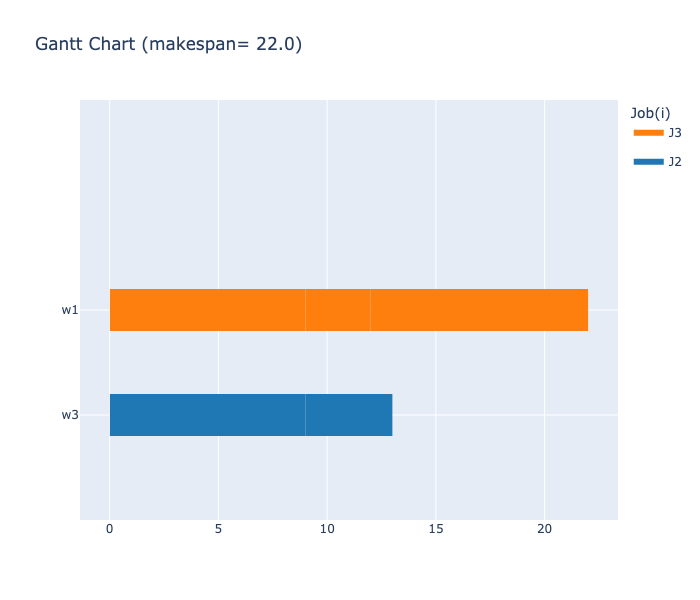

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,penalty_C_max,bool_penalty_C_max,Job_done_before_limit,Elementary task,Metier
0,w1,0.01,9.0,9.0,9.0,"(3,1)",J3,alone,3.594646,2.0,0,before,before,11.0,0.0
1,w1,9.01,12.0,12.0,3.0,"(3,2)",J3,alone,3.594646,3.0,0,before,before,7.0,0.0
2,w1,12.01,22.0,22.0,10.0,"(3,3)",J3,alone,3.594646,3.0,0,before,before,4.0,0.0
3,w3,0.01,9.0,9.0,9.0,"(2,1)",J2,alone,3.693121,3.0,0,before,before,9.0,0.0
4,w3,9.01,13.0,13.0,4.0,"(2,2)",J2,alone without levels,3.693121,4.0,0,before,before,12.0,0.0


In [770]:
gantt_chart(df_test, color=2, render="notebook", separate_little=True)
df_test

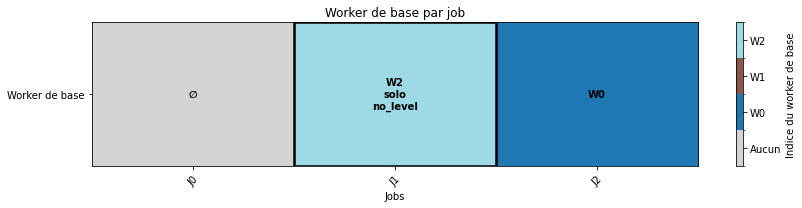

In [771]:
visualize_base_worker_heatmap(best_sol_test.base_worker_assignment, nb_workers=instances[INST_CONSIDERER].nb_workers)

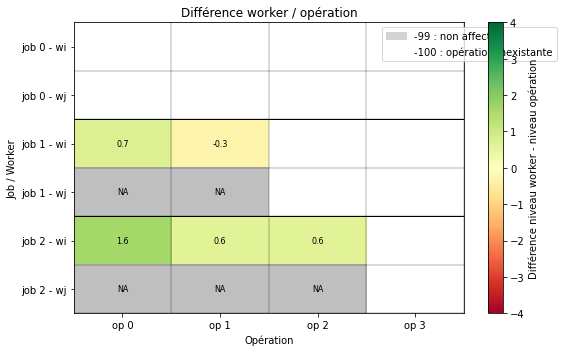

In [772]:
duo_test = get_base_worker_operation(best_sol_test.base_worker_assignment, s_test.x, instances[INST_CONSIDERER])
plot_jobs_heatmap(duo_test)

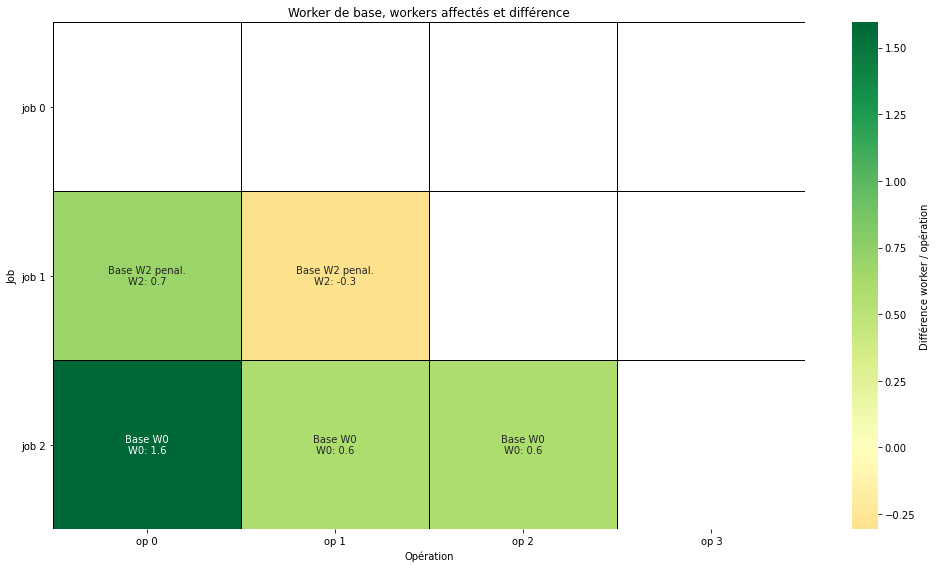

In [ ]:
plot_worker_diff(duo_test, best_sol_test.base_worker_assignment, s_test.x)

---

In [737]:
# gantt_chart(df[INST_CONSIDERER], color=3, render="notebook", separate_little=True)
# df[INST_CONSIDERER]

In [543]:
print(best_solution_test)
ch_copy = deepcopy(best_solution_test)

osc :
[1, 0, 1, 0, 2, 2, 2]
fwac:
[ 0  0 -1 -1  1  1  1]
swac:
[-1 -1 -1 -1 -1 -1 -1]
fitness: 27711.061878703862
objectives: (277.30328911606966, 0.4732967096895724, 0.0)
base_worker_assignment:
[[ 0 -1  1]
 [ 0  0  1]]



In [551]:
print(ch_copy)
print("---------------------------------------------------")
evaluator[4].evaluate_agg(ch_copy)
print("---------------------------------------------------")
print(ch_copy)
s_test.job_done_before_limit, s_test.job_done
# s_test.job_end_dates

osc :
[1, 0, 1, 0, 2, 2, 2]
fwac:
[ 0  0 -1 -1  1  1  1]
swac:
[-1 -1 -1 -1 -1 -1 -1]
fitness: 27711.061878703862
objectives: (277.30328911606966, 0.4732967096895724, 0.0)
base_worker_assignment:
[[ 0 -1  1]
 [ 0  0  1]]

---------------------------------------------------
---------------------------------------------------
osc :
[1, 0, 1, 0, 2, 2, 2]
fwac:
[ 0  0 -1 -1  1  1  1]
swac:
[-1 -1 -1 -1 -1 -1 -1]
fitness: 18883.400750536595
objectives: (189.02667783439696, 0.4732967096895724, 0.0)
base_worker_assignment:
[[ 0 -1  1]
 [ 0  0  1]]



(array([1, 1, 1]), array([1, 0, 1]))

color_map= {'(1,1)': '#636EFA', '(1,2)': '#EF553B', '(3,1)': '#00CC96', '(3,2)': '#AB63FA', '(3,3)': '#FFA15A'}


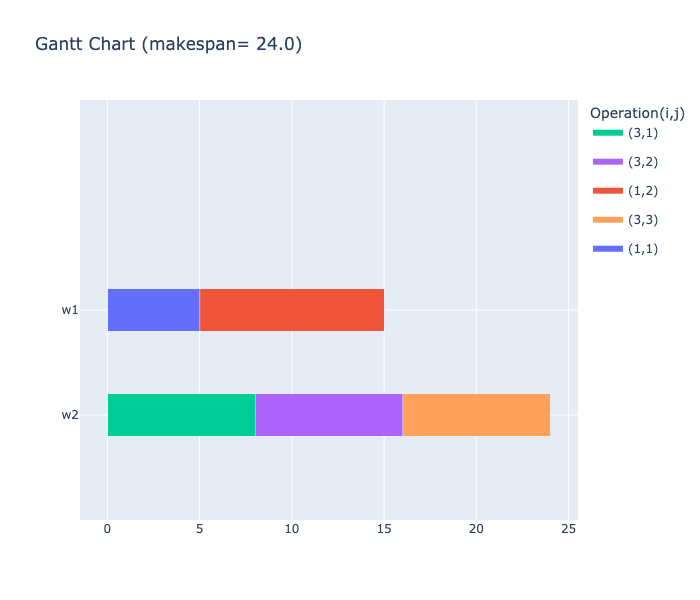

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,penalty_C_max,bool_penalty_C_max,Job_done_before_limit,Elementary task,Metier
0,w1,0.03,5.0,5.0,5.0,"(1,1)",J1,alone,3.792376,3.0,0,before,before,3.0,0.0
1,w1,5.03,15.0,15.0,10.0,"(1,2)",J1,alone,3.792376,2.0,0,before,before,2.0,0.0
2,w2,0.03,8.0,8.0,8.0,"(3,1)",J3,alone,3.526703,2.0,0,before,before,8.0,0.0
3,w2,8.03,16.0,16.0,8.0,"(3,2)",J3,alone,3.526703,4.0,0,before,before,1.0,0.0
4,w2,16.03,24.0,24.0,8.0,"(3,3)",J3,alone,3.526703,2.0,0,before,before,8.0,0.0


In [539]:
gantt_chart(df_test, color=0, render="notebook", separate_little=True)
df_test

In [ ]:
best_solution = multiple_all_list_base_worker[4][-1]
s = decoder.decode_solution(best_solution)
df = scheduling_to_df(s, instance)

In [524]:
instance_idx=4
for nb_seed in range(NB_SEED):
    print(np.max(multiple_all_list_base_worker[4][nb_seed]))

27717.061878703862
27711.061878703862
27717.061878703862
27711.061878703862
27717.061878703862
27717.061878703862
27717.061878703862
27717.061878703862
27717.061878703862
27717.061878703862


In [517]:
np.where(multiple_all_list_base_worker == np.max(multiple_all_list_base_worker))

(array([0, 0, 0, ..., 0, 0, 0]),
 array([0, 0, 0, ..., 9, 9, 9]),
 array([ 84,  85,  86, ..., 497, 498, 499]))

In [320]:
print("Job done:")
print(s.job_done)
print("Job done before limit:")
print(s.job_done_before_limit)
print("worker de base:")
print(s.y)

Job done:
[1. 0. 1.]
Job done before limit:
[1. 0. 1.]
worker de base:
[[0. 1.]
 [0. 0.]
 [1. 0.]]


In [49]:
best_solution = best_list[-1]
s = decoder.decode_solution(best_solution)
df = scheduling_to_df(s, instance)

job_done= [1 0 0]
job_end_dates= [25. -1. -1.]
job_done_before_limit= [1 0 0]
HERRRREE !!!
30.5
HERRRREE !!!
30.5
HERRRREE !!!
30.5


In [50]:
print(best_solution.fitness)
print(best_solution.objectives)
print(s.Cmax)
print(s.borne_sup_makespan, s.job_done_before_limit, s.job_done)
print(s.x)

6880.040601892153
(69.05040601892154, 0.0, 0.0)
25.0
30.5 [1 0 0] [1 0 0]
[[[0. 1.]
  [0. 1.]
  [0. 1.]
  [0. 0.]]

 [[0. 0.]
  [0. 0.]
  [0. 0.]
  [0. 0.]]

 [[0. 0.]
  [0. 0.]
  [0. 0.]
  [0. 0.]]]


In [56]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# diff.shape = (nb_jobs, 2, nb_max_operations)
# base_workers.shape = (2, nb_jobs)
# x_ijk.shape = (nb_jobs, nb_max_operations, nb_workers)

def plot_worker_diff(diff, base_workers, x_ijk):
    nb_jobs, _, nb_ops = diff.shape

    values = np.full((nb_jobs, nb_ops), np.nan)
    labels = np.empty((nb_jobs, nb_ops), dtype=object)

    for i in range(nb_jobs):
        w_base = base_workers[0, i]
        has_penalty = base_workers[1, i]

        for j in range(nb_ops):
            assigned_workers = np.where(x_ijk[i, j, :] == 1)[0]

            if diff[i, 0, j] == -100:
                labels[i, j] = "op inexist."
                continue

            txt = f"Base W{w_base}"
            if has_penalty == 1:
                txt += " penal."

            txt += "\n"

            if len(assigned_workers) == 0:
                txt += "non affecté"
                values[i, j] = -99

            else:
                vals = []
                for idx, w in enumerate(assigned_workers[:2]):
                    v = diff[i, idx, j]
                    vals.append(f"W{w}: {v:.1f}")

                txt += "\n".join(vals)
                values[i, j] = np.nanmean([
                    diff[i, idx, j]
                    for idx in range(min(len(assigned_workers), 2))
                    if diff[i, idx, j] not in [-99, -100]
                ])

            labels[i, j] = txt

    plt.figure(figsize=(14, 8))

    ax = sns.heatmap(
        values,
        annot=labels,
        fmt="",
        cmap="RdYlGn",
        center=0,
        linewidths=0.5,
        linecolor="black",
        cbar_kws={"label": "Différence worker / opération"}
    )

    ax.set_xlabel("Opération")
    ax.set_ylabel("Job")
    ax.set_title("Worker de base, workers affectés et différence")

    ax.set_xticklabels([f"op {j}" for j in range(nb_ops)])
    ax.set_yticklabels([f"job {i}" for i in range(nb_jobs)], rotation=0)

    plt.tight_layout()
    plt.show()

---

# #Big instance

Seed aléatoire pour l'instance : 7422
set
[{3, 4, 11, 15, 18, 23, 26, 27, 31, 33, 34, 39, 40, 44, 45, 46, 50, 51, 54, 55, 58, 61, 66, 73, 74}, {0, 1, 2, 5, 6, 7, 8, 10, 14, 17, 19, 20, 22, 24, 25, 29, 30, 35, 36, 38, 42, 48, 49, 52, 57, 60, 63, 65, 67, 69, 75}, {9, 12, 13, 16, 21, 28, 32, 37, 41, 43, 47, 53, 56, 59, 62, 64, 68, 70, 71, 72, 76}]
ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


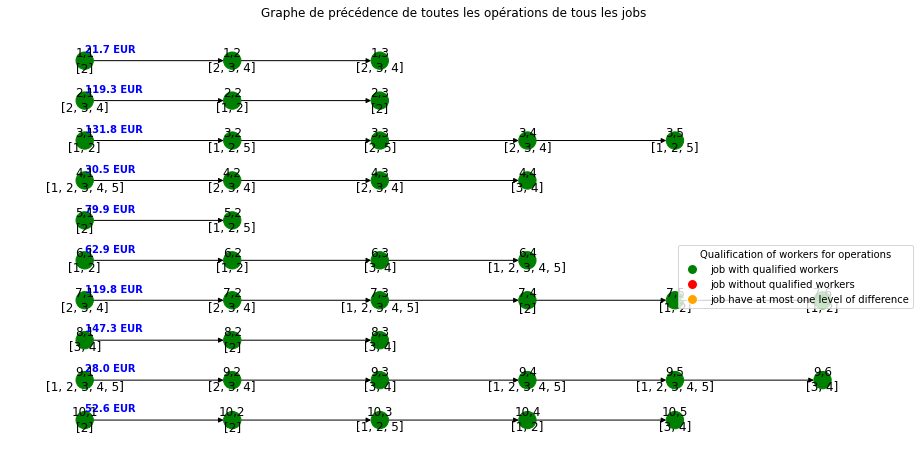

In [38]:
seed = np.random.randint(0, 10000)
print(f"Seed aléatoire pour l'instance : {seed}")
seed = 5083
config_instance = {
    "seed": seed,

    "nb_jobs": 10,
    "nb_workers": 5,
    "nb_professions": 4,
    "proportion_tasks_per_profession": [0.25, 0.25, 0.25, 0.25], # [profession 1, profession 2, profession 3, profession 4]
    "max_nb_operations": 7,
    "nb_tasks" : "lower", # "lower", "medium", "high"

    # "proportion_jobs": [0.3, 0.4, 0.3], # [small_jobs, medium_jobs, long_jobs]

    "proportion_tasks_without_collaborative_work": 0.2,
    "proportion_tasks_level_required": 0.1,

    "proportion_tasks_times" : [0.3, 0.4, 0.3], # [small_tasks (30 unités), medium_tasks (), long_tasks]
    "time_type_of_jobs" : time_type_of_jobs,
    "proportion_tasks_levels":[ 0.1, 0.2, 0.3, 0.4], # [level 1, level 2, level 3, level 4]

    "proportion_workers_levels":[ 0.2, 0.3, 0.2, 0.1], # [level 1, level 2, level 3, level 4]

    "at_least_a_worker_have_competence_for_each_profession": False
}

instance = Instance()
instance.from_config(config_instance)

visualization_before_scheduling(instance, not_qualified=True)

# ##MILP

In [93]:
constraints_config["job_with_no_skills"] = True
constraints_config["constrained_makespan"] = 30 #30

In [94]:
# objective_terms_config["Cmax"] = 0

In [95]:
model = Model(instance)
s = model.solve(objective="lexicographic", weight=weights, priority=[2, 1, 0], constraints_config=constraints_config, verbose=False)


 ========== SOLVING MODEL ========== 
EPS= 0.0001
job with no skills activated
limite MAKESPAN =  30
constrained makespan activated with limit = 30
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 30
init affectation variables desactivated
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 351.0459242295823
nObjectives 3
nSolutions 10
et la -> 30
Borne sup makespan: 30


In [96]:
df = scheduling_to_df(s, instance)

In [97]:
profit = s.resale_price_job_done()
skills = s.sum_skill_levels_rate()
cognitive_load = s.sum_cognitive_load_total()
cmax = s.C_max
print("profit :", profit)
print("skills :", skills)
print("cognitive_load :", cognitive_load)
print("Cmax :", cmax)
print(s.objective_values)
# print("penalty_levels :", np.sum(s[i].penalty_levels))
# expected_fitness = profit*100 + skills*10 - cognitive_load*1- s.C_max
# print("expected_fitness :", expected_fitness)
# assert abs(s.objective_values[0] - expected_fitness) < 1e-6, f"fitness calculée : {s.fitness}, fitness attendue : {expected_fitness}"
# print("---------------------------------------------------")

# row, ok = validate_model_solution(
#     instance=instance,
#     solution=s,
#     constraints_config=constraints_config,
# )
# display(pd.DataFrame([row]))

profit : 292.0459242295823
skills : 2.9999999999997797
cognitive_load : 30.66339648115974
Cmax : 30.0
{0: 351.0459242295823, 1: 2.9999999999997833, 2: -30.66339648115974}


In [98]:
df

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Job_done,Elementary task,Metier
0,w1,0.000000,4.817709,4.817709,4.817709,"(3,1)",J3,collaboratively,4.000000,4.0,True,38.0,2.0
1,w1,17.255570,21.217031,21.217031,3.961461,"(1,1)",J1,alone without levels,2.175527,3.0,True,11.0,0.0
2,w1,21.217031,25.608516,25.608516,4.391484,"(1,2)",J1,alone without levels,1.697176,2.0,True,33.0,1.0
3,w1,25.608516,30.000000,30.000000,4.391484,"(1,3)",J1,alone without levels,1.697176,2.0,True,33.0,1.0
4,w2,0.000000,4.817709,4.817709,4.817709,"(3,1)",J3,collaboratively,4.000000,4.0,True,38.0,2.0
5,w2,4.817709,7.436027,7.436027,2.618318,"(3,2)",J3,alone,4.000000,3.0,True,58.0,3.0
6,w2,7.436027,11.960455,11.960455,4.524427,"(3,3)",J3,alone,4.000000,4.0,True,65.0,3.0
7,w2,11.960455,18.248149,18.248149,6.287694,"(5,1)",J5,alone,4.000000,4.0,True,10.0,0.0
8,w2,18.350512,23.045680,23.045680,4.695168,"(3,4)",J3,collaboratively,3.121592,3.0,True,28.0,1.0
9,w2,23.794898,26.331670,26.331670,2.536772,"(5,2)",J5,learning (tutor),4.000000,3.0,True,74.0,3.0


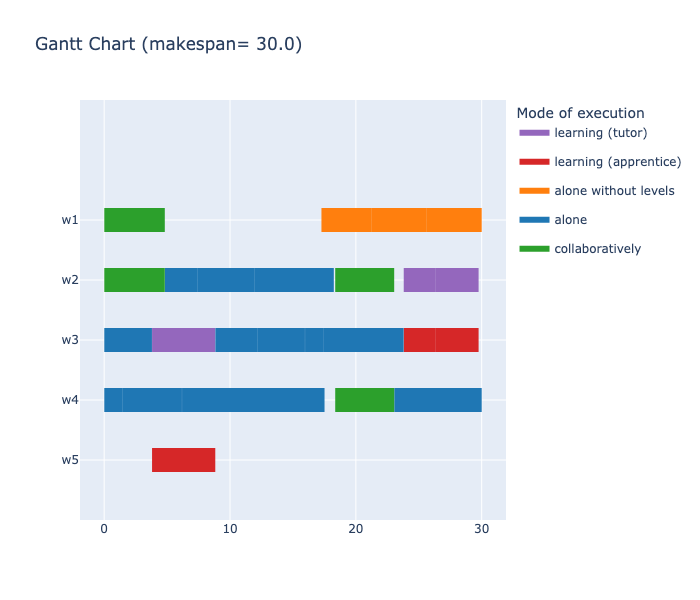

In [99]:
gantt_chart(df, color=3, render="notebook", separate_little=True)

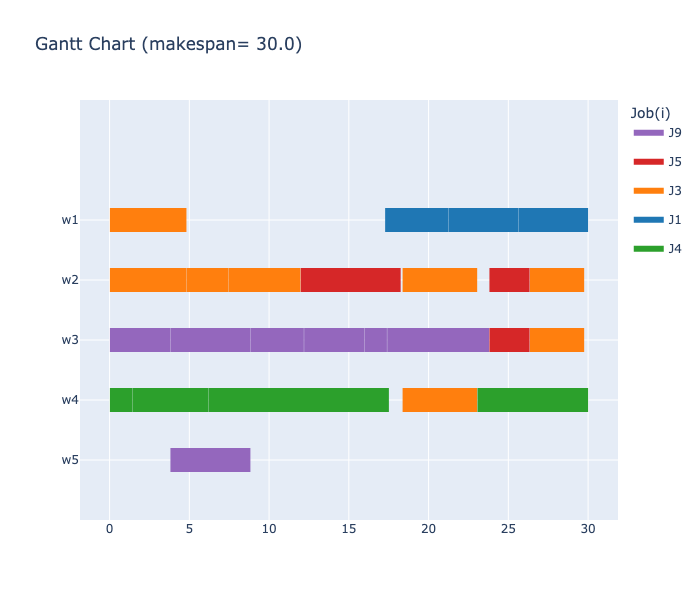

In [100]:
gantt_chart(df, color=2, render="notebook", separate_little=True)

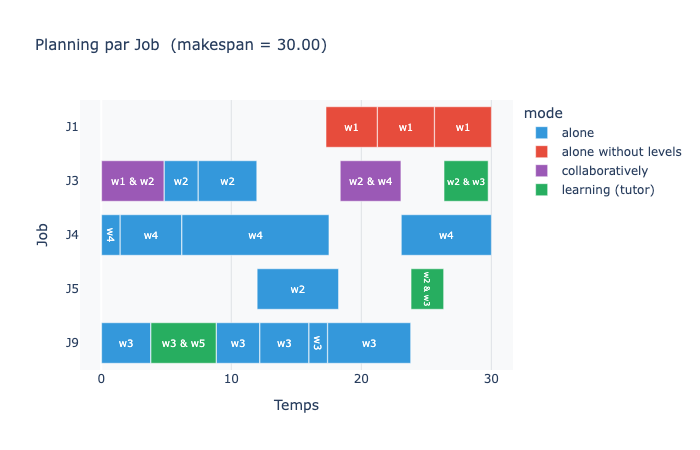

In [101]:
gantt_chart_by_job(df, instance, color_by="mode", render="notebook", save_path=None, separate_little=True)

In [102]:
s.task_done

array([[ 1.,  1.,  1.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 1.,  1.,  1.,  1.,  1.,  0.,  0.],
       [ 1.,  1.,  1.,  1.,  0.,  0.,  0.],
       [ 1.,  1.,  0.,  0.,  0.,  0.,  0.],
       [-0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 1.,  1.,  1.,  1.,  1.,  1.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.]])

In [103]:
for i in range(len(s.y)):
    for j in range(len(s.y[i])):
        if s.y[i][j] == 1:
            print(f"Job {i} has base worker {j}")

Job 0 has base worker 0
Job 2 has base worker 1
Job 3 has base worker 3
Job 4 has base worker 1
Job 8 has base worker 2


In [104]:
row, ok = validate_model_solution(
    instance=instance,
    solution=s,
    constraints_config=constraints_config,
)
display(pd.DataFrame([row]))

,Nom,C_max,Profit_done,Profit_before_limit,Skill_gain,Cognitive_load,solution_valide,base_worker,solo_no_level_difference,OK
0,solution,30.0,292.045924,0,3.0,30.663396,PASS,PASS,PASS,TRUE


In [105]:
print(s.C_max)
print(np.max(s.f))

30.0
30.0


In [106]:
s.C_max - np.max(s.f)

0.0

In [107]:
report = solution_business_report(s, instance)


═══════════════════════════════════════════════════════
  RAPPORT BUSINESS — SOLUTION MILP
═══════════════════════════════════════════════════════

──────────────────── FINANCIER ────────────────────
  Jobs terminés   : 5/10  (50%)
  CA réalisé      : 292.0 EUR  /  potentiel 793.8 EUR  (37%)
  Makespan        : 30.00

─────────────── PROCHAIN SHIFT — JOBS EN COURS ─────
  J2  [░░░░░░░░░░░░░░░░░░░░] 0/3 ops  (0% diff.)  restant ≈27.9u
  J6  [░░░░░░░░░░░░░░░░░░░░] 0/4 ops  (0% diff.)  restant ≈27.4u
  J7  [░░░░░░░░░░░░░░░░░░░░] 0/6 ops  (0% diff.)  restant ≈30.4u
  J8  [░░░░░░░░░░░░░░░░░░░░] 0/3 ops  (0% diff.)  restant ≈20.0u
  J10  [░░░░░░░░░░░░░░░░░░░░] 0/5 ops  (0% diff.)  restant ≈25.2u
  Backlog total estimé : 131.0 unités de temps

────────────────── OCCUPATION WORKERS ──────────────
  w1  occ=58%  ops=4  CL=3.2  [Co:1  S∅:3]
  w2  occ=96%  ops=7  CL=11.5  [Solo:3  Tu:2  Co:2]
  w3  occ=99%  ops=8  CL=9.2  [Solo:5  Tu:1  Ap:2]
  w4  occ=97%  ops=5  CL=2.6  [Solo:4  Co:1]
  w5  oc

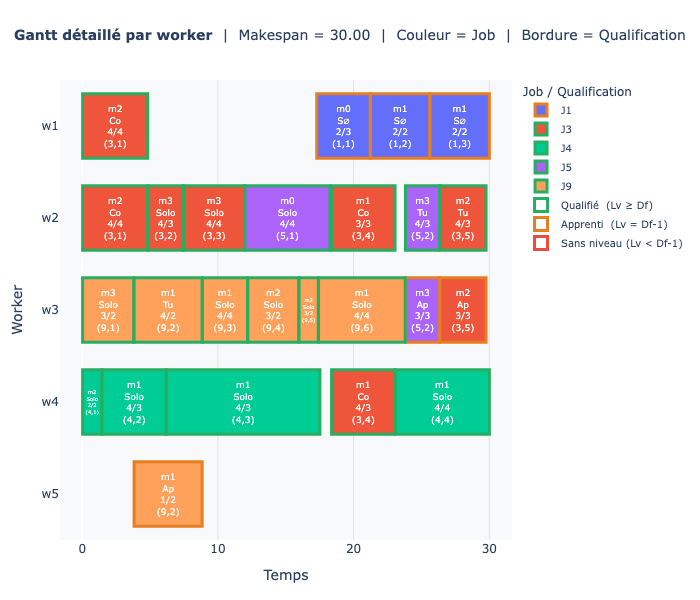

In [108]:
gantt_chart_rich(df, render="notebook", save_path=None)

In [109]:
plot_business_report(report, instance, save_path=None)

In [110]:
instance.visualize_jobs_overview()

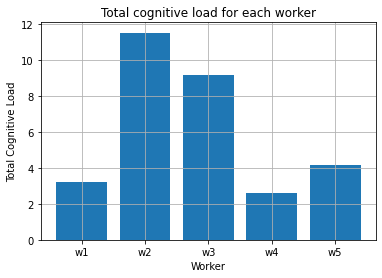

In [111]:
bars_cognitive_load_total(s, instance)

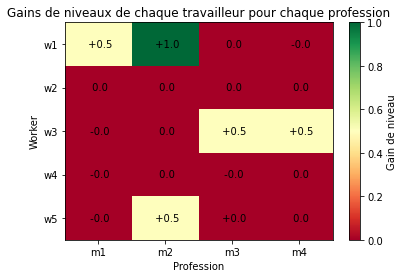

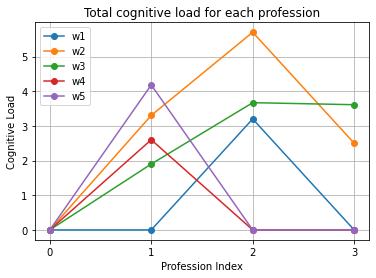

In [115]:
resume_levels_workers(s, instance)
plot_cognitive_load_total(s, instance)

--- Max que le profit

In [ ]:
weights = {
    "profit" : 1,
    "skills" : 0,
    "cognitive_load" : 0
    }

model = Model(instance)
s = model.solve(objective="three", weight=weights, priority=[2, 1, 0], constraints_config=constraints_config, verbose=False)


 ========== SOLVING MODEL ========== 
EPS= 0.0001
job with no skills activated
limite MAKESPAN =  30
constrained makespan activated with limit = 30
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 30
init affectation variables desactivated
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 351.0459242295823
nObjectives 1
nSolutions 8
et la -> 30
Borne sup makespan: 30


In [118]:
df = scheduling_to_df(s, instance)
df

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Job_done,Elementary task,Metier
0,w1,3.631267,7.592728,7.592728,3.961461,"(1,1)",J1,alone without levels,2.175527,3.0,True,11.0,0.0
1,w1,7.592728,12.410437,12.410437,4.817709,"(3,1)",J3,collaboratively,4.000000,4.0,True,38.0,2.0
2,w1,12.410437,14.617328,14.617328,2.206891,"(9,4)",J9,collaboratively,4.000000,2.0,True,55.0,2.0
3,w1,14.617328,19.008812,19.008812,4.391484,"(1,2)",J1,alone without levels,1.697176,2.0,True,33.0,1.0
4,w1,25.608516,30.000000,30.000000,4.391484,"(1,3)",J1,alone without levels,1.697176,2.0,True,33.0,1.0
5,w2,0.000000,6.287694,6.287694,6.287694,"(5,1)",J5,alone,4.000000,4.0,True,10.0,0.0
6,w2,6.287694,7.592728,7.592728,1.305034,"(5,2)",J5,alone,4.000000,3.0,True,74.0,3.0
7,w2,7.592728,12.410437,12.410437,4.817709,"(3,1)",J3,collaboratively,4.000000,4.0,True,38.0,2.0
8,w2,12.763949,15.382267,15.382267,2.618318,"(3,2)",J3,alone,4.000000,3.0,True,58.0,3.0
9,w2,15.382267,19.906695,19.906695,4.524427,"(3,3)",J3,alone,4.000000,4.0,True,65.0,3.0


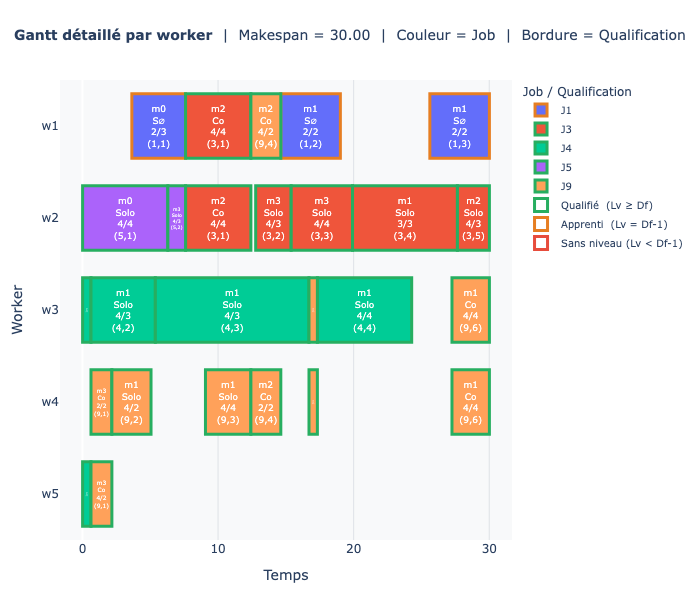

In [119]:
gantt_chart_rich(df, render="notebook", save_path=None)

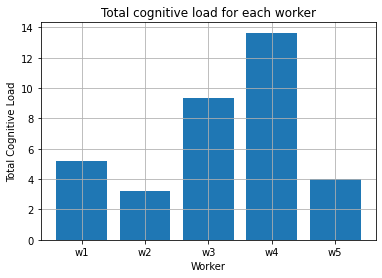

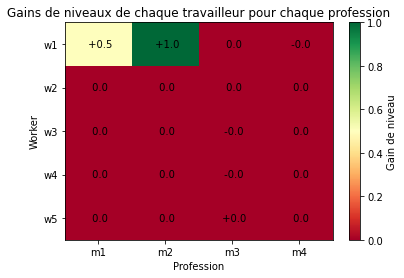

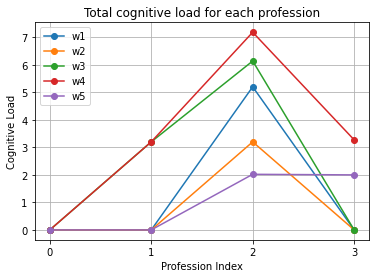

In [120]:
bars_cognitive_load_total(s, instance)
resume_levels_workers(s, instance)
plot_cognitive_load_total(s, instance)

In [113]:
# report

In [480]:
# print(instance)

In [434]:
instance.time_each_job_alone()

[14.669419722119455,
 26.372552970161777,
 27.532954120121772,
 16.5100558679517,
 7.040733053048539,
 15.97308652359645]

In [484]:
# print(instance.constraints_precedence_operations[2])
print(s.x[2,:,:])
print(s.f[2,:,:])
print(s.task_done[2,:])

[[0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]
[[ 2.23443069  2.23443069  2.23443069  2.23443069  2.23443069  2.23443069]
 [ 3.47416104  3.47416104  3.47416104  5.70859173  3.47416104  3.47416104]
 [ 3.14237489  3.14237489  3.14237489  8.85096662  3.14237489  3.14237489]
 [ 2.12085177  2.12085177  2.12085177 10.97181839  2.12085177  2.12085177]
 [ 6.3963778   6.3963778  18.67572374  6.3963778   6.3963778   6.3963778 ]
 [ 0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.        ]]
[1. 1. 1. 1. 1. 0. 0.]


In [421]:
check_df(df)
# df

 ========== CHECKING CONDITIONS FOR GANTT CHART ========== 
df_grouped=
   Operation                   mode  count
0      (1,1)                  alone      1
1      (1,2)  learning (apprentice)      1
2      (1,2)       learning (tutor)      1
3      (1,3)                  alone      1
4      (2,1)  learning (apprentice)      1
5      (2,1)       learning (tutor)      1
6      (3,1)  learning (apprentice)      1
7      (3,1)       learning (tutor)      1
8      (3,2)                  alone      1
9      (3,3)                  alone      1
10     (3,4)  learning (apprentice)      1
11     (3,4)       learning (tutor)      1
12     (3,5)                  alone      1
13     (4,1)                  alone      1
14     (4,2)                  alone      1
15     (4,3)                  alone      1
16     (5,1)  learning (apprentice)      1
17     (5,1)       learning (tutor)      1
18     (5,2)                  alone      1
19     (6,1)                  alone      1
All conditions are satisf

True

In [422]:
df

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Job_done,Elementary task,Metier
0,w1,0.000000,2.274153,2.274153,2.274153,"(3,1)",J3,learning (apprentice),2.346064,3.0,False,38.0,3.0
1,w1,2.274153,5.458527,5.458527,3.184374,"(1,1)",J1,alone,4.000000,4.0,True,9.0,0.0
2,w1,5.458527,14.553499,14.553499,9.094972,"(1,2)",J1,learning (apprentice),2.346064,3.0,True,37.0,3.0
3,w1,15.006561,20.000000,20.000000,4.993439,"(1,3)",J1,alone,4.000000,4.0,True,10.0,0.0
4,w2,0.000000,7.831981,7.831981,7.831981,"(2,1)",J2,learning (apprentice),2.278227,3.0,False,43.0,3.0
5,w2,9.244432,17.849710,17.849710,8.605278,"(5,1)",J5,learning (apprentice),2.136971,3.0,True,11.0,1.0
6,w2,17.849710,20.000000,20.000000,2.150290,"(5,2)",J5,alone,2.215934,2.0,True,3.0,0.0
7,w3,0.000000,7.831981,7.831981,7.831981,"(2,1)",J2,learning (tutor),4.000000,3.0,False,43.0,3.0
8,w3,7.831981,10.974356,10.974356,3.142375,"(3,3)",J3,alone,1.373018,1.0,False,17.0,1.0
9,w3,11.877494,13.531820,13.531820,1.654326,"(3,4)",J3,learning (apprentice),2.371560,3.0,False,1.0,0.0


# ##Local Search

In [289]:
ONE_NB_SEED = 10
ONE_MAX_ITER = 200

enc   = Encoding_Dicos(instance)
gen   = ChromosomeGenerator(instance, enc, constraints_config=constraints_config)
dec   = Decoder(instance, enc, constraints_config=constraints_config)
eval  = Evaluator(dec, weights, objective_terms_config=objective_terms_config)
sel   = BestSelector()

n_base_worker = ChangebaseWorkerNeighborhood(nb_job_no_skills=1, generator=gen)
n_swap_op = SwapOperationNeighborhood(3)
n_multiple_cumulative = multipleNeighborhood_cumulative(n_base_worker, n_swap_op)
n_multiple_alternating = multipleNeighborhood_alternating(n_base_worker, n_swap_op)

ls_bw  = LocalSearch(gen, eval, n_base_worker, sel)
ls_sw  = LocalSearch(gen, eval, n_swap_op, sel)
ls_cu  = LocalSearch(gen, eval, n_multiple_cumulative, sel)
ls_al  = LocalSearch(gen, eval, n_multiple_alternating, sel)

In [290]:
# ── Runs sur ONE_NB_SEED seeds ────────────────────────────────────────────────
all_bw,  best_bw  = [], []
all_sw,  best_sw  = [], []
all_cu,  best_cu  = [], []
all_al,  best_al  = [], []

fit_bw, fit_sw, fit_cu, fit_al = [], [], [], []

for seed_id in range(ONE_NB_SEED):
    print(f"\nSeed {seed_id + 1}/{ONE_NB_SEED}")

    al, bl = ls_bw.run(ONE_MAX_ITER, verbose=True)
    all_bw.append(al); best_bw.append(bl)
    fit_bw.append([s.fitness for s in al])
    print()

    al, bl = ls_sw.run(ONE_MAX_ITER, verbose=True)
    all_sw.append(al); best_sw.append(bl)
    fit_sw.append([s.fitness for s in al])
    print()

    al, bl = ls_cu.run(ONE_MAX_ITER, verbose=True)
    all_cu.append(al); best_cu.append(bl)
    fit_cu.append([s.fitness for s in al])
    print()

    al, bl = ls_al.run(ONE_MAX_ITER, verbose=True)
    all_al.append(al); best_al.append(bl)
    fit_al.append([s.fitness for s in al])
    print()

fit_bw = np.array(fit_bw)
fit_sw = np.array(fit_sw)
fit_cu = np.array(fit_cu)
fit_al = np.array(fit_al)

print("Terminé.")


Seed 1/10
Initial fitness: 41086.35799421263
iter 1: New best fitness: 41104.844462771085
iter 2: New best fitness: 41115.12951269028
iter 16: New best fitness: 41118.59284214987
iter 71: New best fitness: 41118.93592270872
iter 76: New best fitness: 41119.26215551342
iter 78: New best fitness: 41121.92121979904

Initial fitness: 46585.07627945248

Initial fitness: 34516.81004866524
iter 1: New best fitness: 34519.01138085358
iter 3: New best fitness: 34530.649151665595
iter 8: New best fitness: 34538.13280997845
iter 9: New best fitness: 34542.86155850118
iter 73: New best fitness: 34547.43479601201
iter 170: New best fitness: 34553.14723364043

Initial fitness: 41084.51813241207
iter 2: New best fitness: 41102.9260090746
iter 6: New best fitness: 41110.712285402085
iter 10: New best fitness: 41111.00186349971
iter 14: New best fitness: 41114.88992880888
iter 15: New best fitness: 41115.62726835849
iter 16: New best fitness: 41116.58177815486
iter 39: New best fitness: 41116.67317672

## #Décodage du meilleur choromosome pour chaque voisinage

In [305]:
i_max = np.argmax(fit_bw[:,-1])
print(i_max)
best_bw[i_max][-1].fitness
s_best_bw = dec.decode_solution(best_bw[i_max][-1])
df_best_bw = scheduling_to_df(s_best_bw, instance)

j_max = np.argmax(fit_sw[:,-1])
print(j_max)
best_sw[j_max][-1].fitness
s_best_sw = dec.decode_solution(best_sw[j_max][-1])
df_best_sw = scheduling_to_df(s_best_sw, instance)

k_max = np.argmax(fit_cu[:,-1])
print(k_max)
best_cu[k_max][-1].fitness
s_best_cu = dec.decode_solution(best_cu[k_max][-1])
df_best_cu = scheduling_to_df(s_best_cu, instance)

l_max = np.argmax(fit_al[:,-1])
print(l_max)
best_al[l_max][-1].fitness
s_best_al = dec.decode_solution(best_al[l_max][-1])
df_best_al = scheduling_to_df(s_best_al, instance)

5
1
1
8


In [312]:
print(best_bw[i_max][-1])
print(best_sw[j_max][-1])
print(best_cu[k_max][-1])
print(best_al[l_max][-1])

osc :
[1, 1, 1, 1, 3, 3, 3, 5, 5, 5, 0, 0, 0, 2, 2, 2, 2, 2, 2, 4, 4]
fwac:
[ 0  5  0 -1 -1 -1 -1  4  4  4  4  4  4  4  4  4  1  1 -1 -1 -1]
swac:
[-1  0 -1 -1 -1 -1 -1  3 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1]
fitness: 46628.81136315283
objectives: (466.89075292987206, 2.0, 18.198568847785296)
base_worker_assignment:
[[ 0 -1  4  4  1 -1]
 [ 0 -1  1  0  0 -1]]

osc :
[3, 4, 1, 4, 3, 0, 3, 5, 2, 1, 5, 2, 2, 2, 1, 2, 2, 0, 1, 0, 5]
fwac:
[ 0  3  0 -1 -1 -1 -1  4  4  4  4  4  4  4  4  4  1  0 -1 -1 -1]
swac:
[-1  0 -1 -1 -1 -1 -1  1  3  2  0  2 -1  3  3  0 -1  1 -1 -1 -1]
fitness: 46597.71005044271
objectives: (466.89075292987206, 3.0, 60.79187954918901)
base_worker_assignment:
[[ 0 -1  4  4  1 -1]
 [ 0 -1  1  0  0 -1]]

osc :
[0, 0, 0, 3, 3, 3, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 4, 4, 5, 5, 5]
fwac:
[ 0  2  0 -1 -1 -1 -1  4  4  4  4  4  4  4  4  4  1  1 -1 -1 -1]
swac:
[-1  0 -1 -1 -1 -1 -1  0 -1  0  3  3 -1 -1 -1 -1 -1 -1 -1 -1 -1]
fitness: 46629.99069764843
objectives: (466.89075292987206,

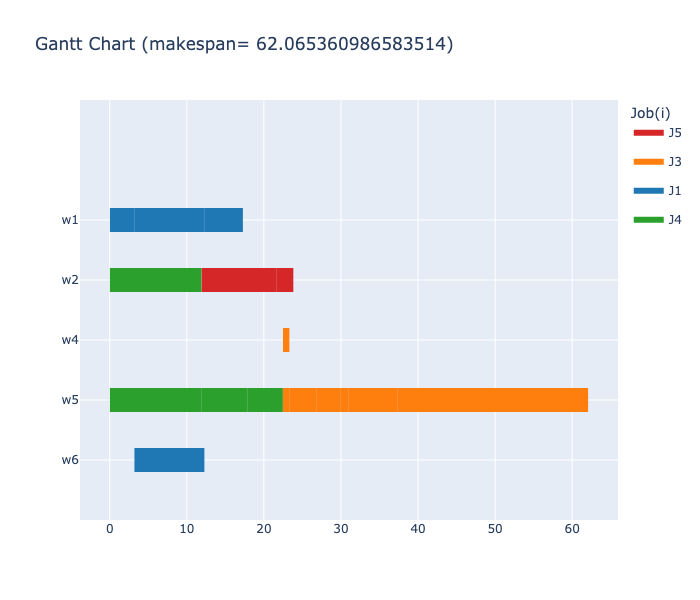

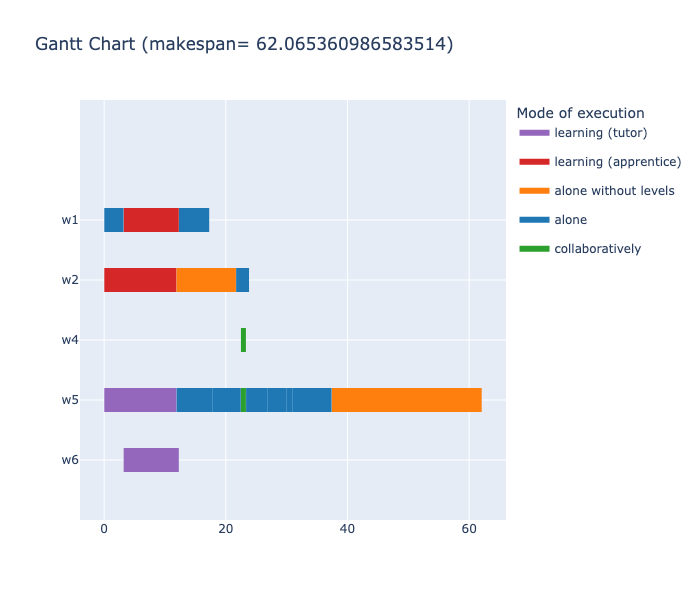

In [307]:
gantt_chart(df_best_bw, color=2, render="notebook", separate_little=True)
gantt_chart(df_best_bw, color=3, render="notebook", separate_little=True)

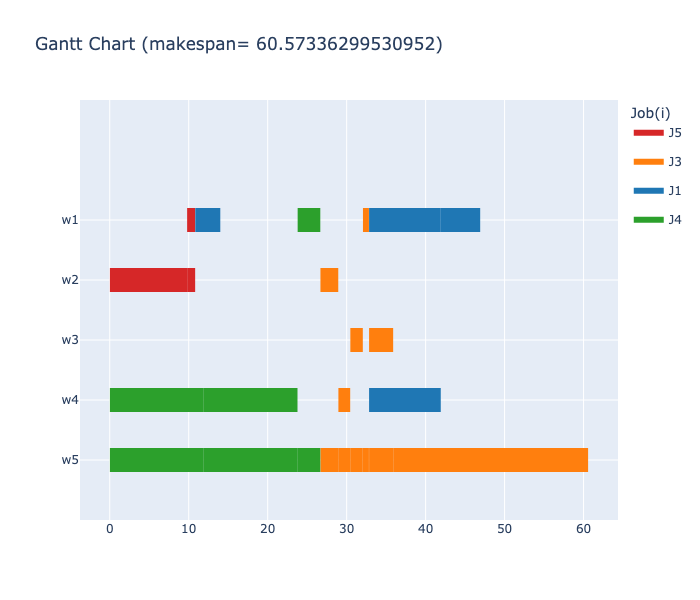

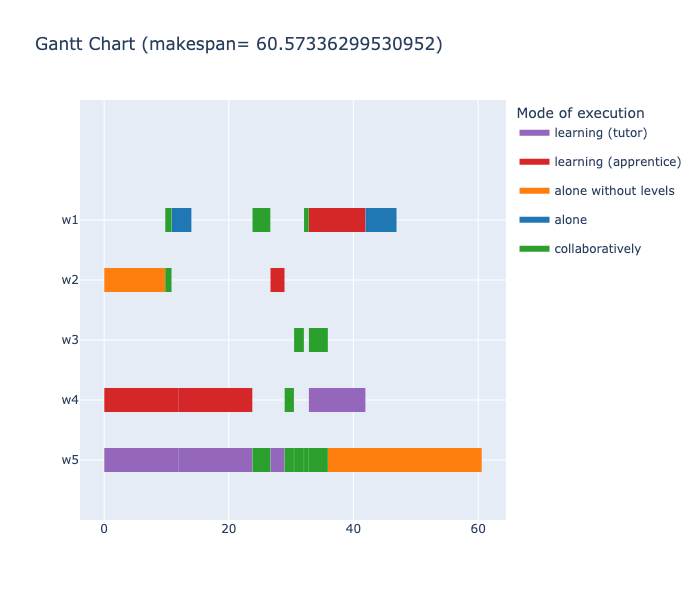

In [308]:
gantt_chart(df_best_sw, color=2, render="notebook", separate_little=True)
gantt_chart(df_best_sw, color=3, render="notebook", separate_little=True)

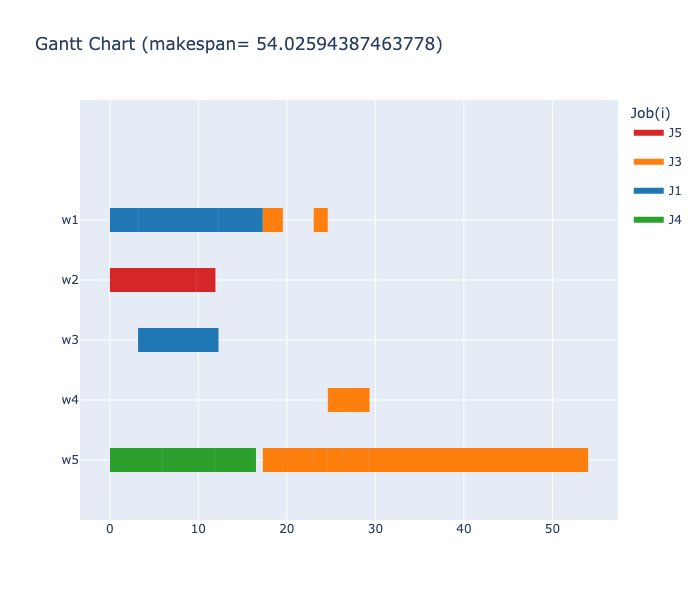

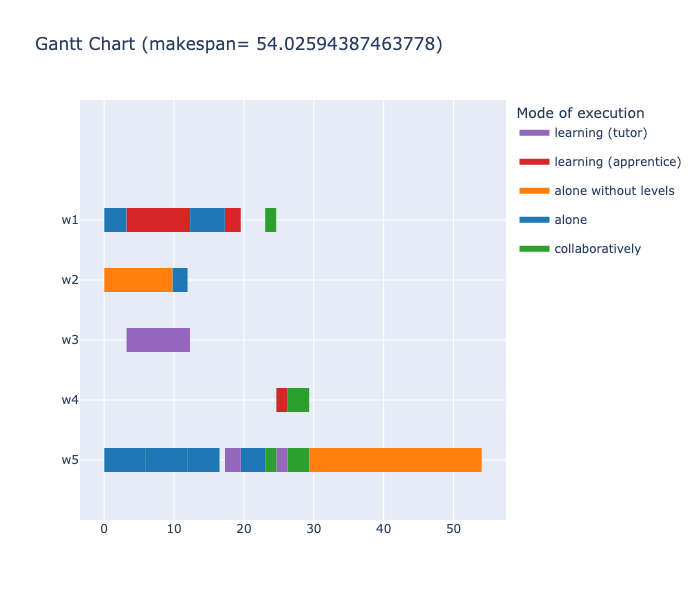

In [309]:
gantt_chart(df_best_cu, color=2, render="notebook", separate_little=True)
gantt_chart(df_best_cu, color=3, render="notebook", separate_little=True)

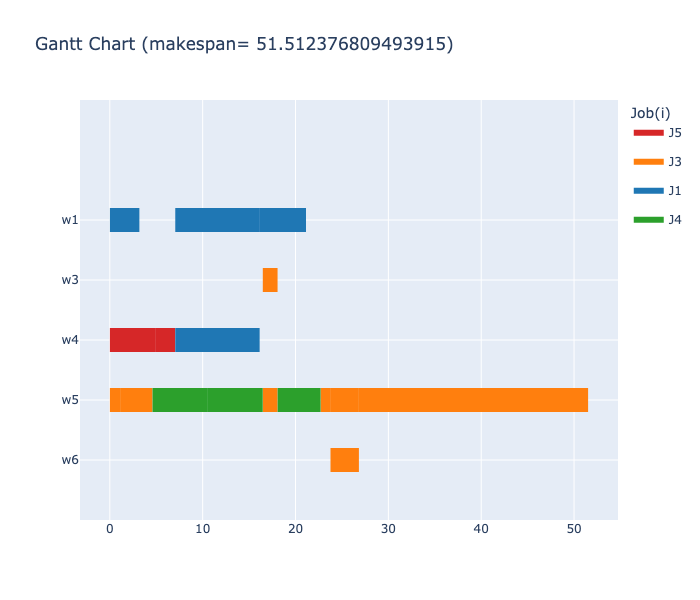

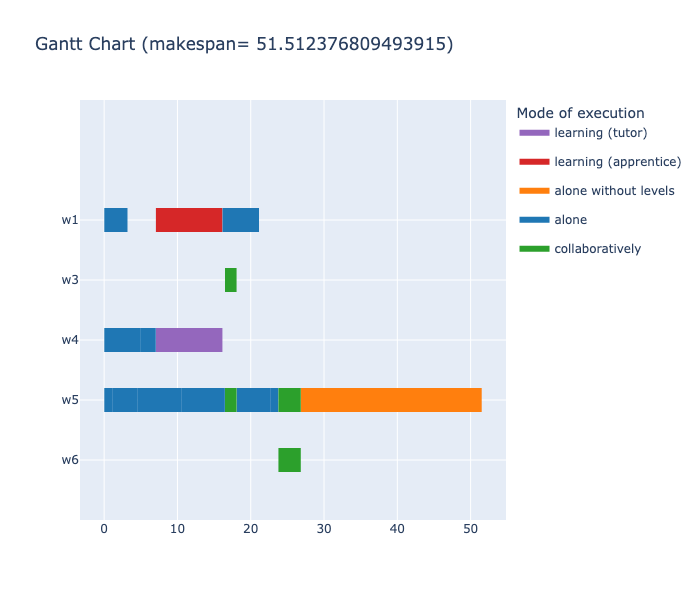

In [310]:
gantt_chart(df_best_al, color=2, render="notebook", separate_little=True)
gantt_chart(df_best_al, color=3, render="notebook", separate_little=True)

In [313]:
import pandas as pd

fitness_milp = s.objective_values[0]

def _summary(arr, name):
    best_per_seed = arr[:, -1]
    return {
        "Méthode":      name,
        "Fitness max":  round(float(np.max(best_per_seed)), 2),
        "Fitness moy.": round(float(np.mean(best_per_seed)), 2),
        "Fitness std":  round(float(np.std(best_per_seed)), 2),
        "Gap MILP (%)": round(100 * (fitness_milp - float(np.max(best_per_seed))) / abs(fitness_milp), 2)
                         if fitness_milp != 0 else None,
    }

rows = [
    {"Méthode": "MILP (exact)", "Fitness max": round(fitness_milp, 2),
     "Fitness moy.": "-", "Fitness std": "-", "Gap MILP (%)": 0.0},
    _summary(fit_bw, "Base Worker"),
    _summary(fit_sw, "Swap"),
    _summary(fit_cu, "Cumulative"),
    _summary(fit_al, "Alternating"),
]

df_cmp = pd.DataFrame(rows)
df_cmp

,Méthode,Fitness max,Fitness moy.,Fitness std,Gap MILP (%)
0,MILP (exact),46636.27,-,-,0.00
1,Base Worker,46628.81,42559.17,4659.01,0.02
2,Swap,46597.71,43180.15,3885.06,0.08
3,Cumulative,46629.99,40696.25,5403.74,0.01
4,Alternating,46630.90,42558.84,4659.35,0.01


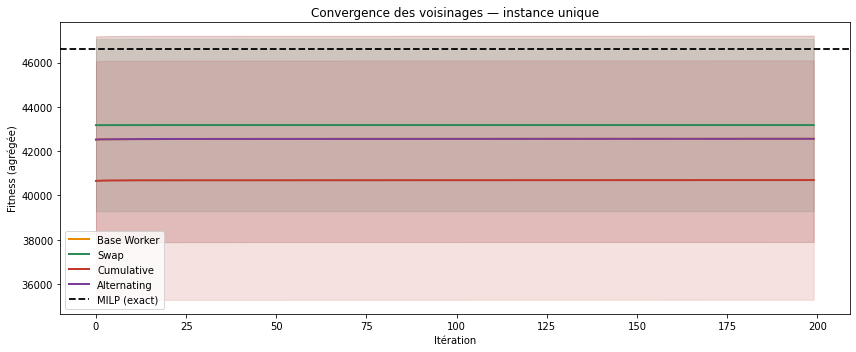

In [292]:
fig, ax = plt.subplots(figsize=(12, 5))

colors_ls = {"Base Worker": "#E88B00", "Swap": "#2E8B57",
             "Cumulative": "#C0392B", "Alternating": "#7D3C98"}

for arr, name in [(fit_bw, "Base Worker"), (fit_sw, "Swap"),
                  (fit_cu, "Cumulative"), (fit_al, "Alternating")]:
    mean = np.mean(arr, axis=0)
    std  = np.std(arr,  axis=0)
    iters = np.arange(len(mean))
    col = colors_ls[name]
    ax.plot(iters, mean, label=name, color=col, lw=2)
    ax.fill_between(iters, mean - std, mean + std, color=col, alpha=0.15)

ax.axhline(fitness_milp, color="black", ls="--", lw=1.8, label="MILP (exact)")
ax.set_xlabel("Itération")
ax.set_ylabel("Fitness (agrégée)")
ax.set_title("Convergence des voisinages — instance unique")
ax.legend()
plt.tight_layout()
plt.show()

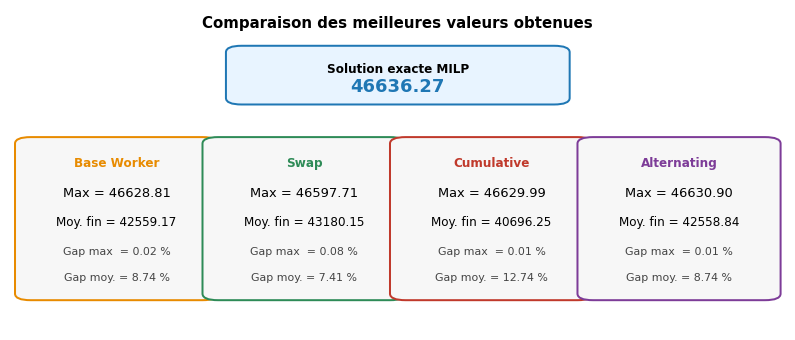

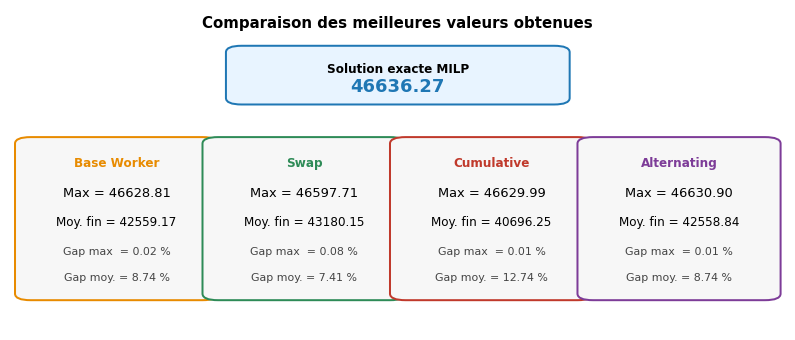

In [314]:
fitness_per_method = {
    "Base Worker": fit_bw,
    "Swap": fit_sw,
    "Cumulative": fit_cu,
    "Alternating": fit_al,
}

plot_comparison_cards(
    fitness_per_method,
    fitness_milp,
    title="Comparaison des meilleures valeurs obtenues",
    save_path=None,
    figsize=(14, 6),
)

In [285]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

METHOD_COLORS = {
    "Base Worker": "#E88B00",
    "Swap":        "#2E8B57",
    "Cumulative":  "#C0392B",
    "Alternating": "#7D3C98",
}


def plot_comparison_cards(
    fitness_per_method,
    fitness_milp,
    title="Comparaison des meilleures valeurs obtenues",
    save_path=None,
    figsize=(14, 6),
):
    """
    Affiche des cartes comparant MILP et chaque voisinage de recherche locale.

    Parameters
    ----------
    fitness_per_method : dict
        { "Base Worker": np.array (nb_seeds, nb_iter), "Swap": ..., ... }
    fitness_milp : float
        Valeur fitness MILP de référence.
    title : str
        Titre affiché en haut de la figure.
    save_path : str or None
        Chemin PNG de sauvegarde (None = pas de sauvegarde).
    figsize : tuple

    Returns
    -------
    fig : matplotlib.Figure

    Exemples
    --------
    # Instance unique
    plot_comparison_cards(
        {"Base Worker": one_fit_bw, "Swap": one_fit_sw,
         "Cumulative": one_fit_cu, "Alternating": one_fit_al},
        fitness_milp=one_fitness_milp,
        title="Instance unique",
        save_path="comparaison_single.png",
    )

    # Multi-instances (dans une boucle)
    for inst_id in range(NB_INSTANCES):
        plot_comparison_cards(
            {"Base Worker": multiple_fitness_base_worker[inst_id],
             "Swap":        multiple_fitness_swap[inst_id],
             "Cumulative":  multiple_fitness_cumulative[inst_id],
             "Alternating": multiple_fitness_alternating[inst_id]},
            fitness_milp=fitness_exacte_by_instance[inst_id],
            title=f"Instance {inst_id}",
            save_path=f"comparaison_instance_{inst_id}.png",
        )
    """

    # ── statistiques par méthode ──────────────────────────────────────────────
    results = []
    for name, arr in fitness_per_method.items():
        arr = np.array(arr)
        if arr.ndim == 1:
            arr = arr.reshape(1, -1)
        results.append((
            name,
            float(np.max(arr)),
            float(np.mean(arr[:, -1])),
        ))

    def _gap(ref, val):
        return 100 * (ref - val) / abs(ref) if abs(ref) > 1e-9 else None

    # ── figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    # Titre
    ax.text(0.5, 0.95, title,
            ha="center", va="center", fontsize=15, fontweight="bold",
            transform=ax.transAxes)

    # Carte MILP
    ax.add_patch(FancyBboxPatch(
        (0.30, 0.72), 0.40, 0.14,
        boxstyle="round,pad=0.02", linewidth=2,
        facecolor="#E8F4FF", edgecolor="#1F77B4",
        transform=ax.transAxes, clip_on=False,
    ))
    ax.text(0.50, 0.81, "Solution exacte MILP",
            ha="center", va="center", fontsize=12, fontweight="bold",
            transform=ax.transAxes)
    ax.text(0.50, 0.755, f"{fitness_milp:.2f}",
            ha="center", va="center", fontsize=18, fontweight="bold",
            color="#1F77B4", transform=ax.transAxes)

    # Cartes méthodes
    n      = len(results)
    margin = 0.03
    width  = (1 - 2 * margin - (n - 1) * 0.02) / n
    y0, h  = 0.12, 0.46

    for idx, (name, max_val, mean_final) in enumerate(results):
        x   = margin + idx * (width + 0.02)
        cx  = x + width / 2
        col = METHOD_COLORS.get(name, "#888888")

        gap_max  = _gap(fitness_milp, max_val)
        gap_mean = _gap(fitness_milp, mean_final)

        ax.add_patch(FancyBboxPatch(
            (x, y0), width, h,
            boxstyle="round,pad=0.02", linewidth=2,
            facecolor="#F7F7F7", edgecolor=col,
            transform=ax.transAxes, clip_on=False,
        ))
        ax.text(cx, y0 + 0.40, name,
                ha="center", va="center", fontsize=12, fontweight="bold",
                color=col, transform=ax.transAxes)
        ax.text(cx, y0 + 0.31, f"Max = {max_val:.2f}",
                ha="center", va="center", fontsize=13, transform=ax.transAxes)
        ax.text(cx, y0 + 0.22, f"Moy. fin = {mean_final:.2f}",
                ha="center", va="center", fontsize=12, transform=ax.transAxes)
        ax.text(cx, y0 + 0.13,
                f"Gap max  = {gap_max:.2f} %"  if gap_max  is not None else "Gap = N/A",
                ha="center", va="center", fontsize=11, color="#444",
                transform=ax.transAxes)
        ax.text(cx, y0 + 0.05,
                f"Gap moy. = {gap_mean:.2f} %" if gap_mean is not None else "Gap = N/A",
                ha="center", va="center", fontsize=11, color="#444",
                transform=ax.transAxes)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    return fig
